In [1]:

#Importing Important Stuff
import scipy.interpolate as interpolate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics as stat 
import math 
from pylab import *
import os
import fmEphys as fme
import sys
import scipy
sys.path.append(r"C:\Users\Niell Lab\Documents\GitHub\freely-moving-saccades")
import saccadeAnalysis as sacc
import sklearn.cluster
import fmEphys as fme
import pickle


def norm_psth(psth_pre, psth_post):
    kernel_size = 25
    kernel = np.ones(kernel_size) / kernel_size

    #psth_pre = np.convolve(psth_pre, kernel, mode='same')
    #psth_post = np.convolve(psth_post, kernel, mode='same')
    
    #subtract off baseline value
    baselined_psth_pre = psth_pre - np.nanmean(psth_pre[200:950].astype(float))
    baselined_psth_post = psth_post - np.nanmean(psth_post[200:950].astype(float))

    #find max FR before and after injection
    mx_pre = np.nanmax(np.abs(baselined_psth_pre[750:1500]))
    mx_post = np.nanmax(np.abs(baselined_psth_post[750:1500]))
    Mx = np.nanmax([mx_pre,mx_post])

    #normalize psth to max
    norm_psth_pre = baselined_psth_pre/Mx
    norm_psth_post = baselined_psth_post/Mx

    return norm_psth_pre, norm_psth_post 

def calc_PSTH(spikeT, eventT, bandwidth=10, resample_size=1, edgedrop=15, win=1000, num_events=None):
    """
    calcualtes for a single cell at a time

    bandwidth (in msec)
    resample_size (msec)
    edgedrop (msec to drop at the start and end of the window so eliminate artifacts of filtering)
    win = 1000msec before and after
    """

    # Some conversions
    bandwidth = bandwidth / 1000
    resample_size = resample_size / 1000
    win = win / 1000
    edgedrop = edgedrop / 1000
    edgedrop_ind = int(edgedrop / resample_size)

    # Setup time bins. The bins of the returned PSTH will be -`win` msec to +`win` msec
    # with `resame_size` msec bins, where 0 is the time of the event. Because of edge effects
    # from the gaussian filter, we'll calculate the PSTH with an extra `edgedrop` msec at the
    # start and end so that the edges of the PSTH can be dropped without losing timepoints
    # we care about.
    bins = np.arange(-win-edgedrop, win+edgedrop+resample_size, resample_size)

    # if there is only one event time (i.e. if it's an int for all spikes like eventT=np.array(0)
    if np.size(eventT)>1:

        # Get the timestamps of spikes relative to events in `eventT`
        sps = []
        for i, t in enumerate(eventT):
            sp = spikeT-t
            # Only keep spikes in this window
            sp = sp[(sp <= (win+edgedrop)) & (sp >= (-win-edgedrop))]
            sps.extend(sp)
        num_events = np.size(eventT)
    else:
        sps = eventT.copy().flatten()
    
    # If `win` is 1000 msec, values in `sps` will fall between -1 and 1, since only spikes
    # that fall before or after the event by 1 second are included.
    # (Because of `edge_drop`, values can be a bit beyond `win` but those will be eliminated before
    # the PSTH is returned.
    sps = np.array(sps)

    # Calculate the PSTH using Kernel Density Estimation
    kernel = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(sps[:, np.newaxis])
    density = kernel.score_samples(bins[:, np.newaxis])

    # Here, `density` is a probability function that sums to 1. We want it in sp/sec.
    # We need to multiply by the # spikes to get the spike count per point. Then,
    # we divide by the number of events so that we get teh rate per event.
    psth = np.exp(density) * (np.size(sps) / num_events)

    # Drop the extra time at the start and end of the window, since it will have
    # edge effects from the gaussian filter. After dropping this, it will be the
    # size set by `win`, so no important timepoints are actually lost here.
    psth = psth[edgedrop_ind:-edgedrop_ind]

    return psth

def calc_std_modidx(psth,thresh,trange = 'fm'):
    if trange == 'fm':
        psth = psth.astype(float)
        psth = psth - np.nanmean(psth[100:800])

        std_thresh = np.nanstd(psth[100:800]*thresh)
    
        if np.nanmax((np.abs(psth[975:1500])-std_thresh)) > 0:
            mod = 1
        else:
            mod = 0 

    elif trange == 'gt':
        psth = psth.astype(float)
        psth = psth - np.nanmean(psth[1100:1400])

        std_thresh = np.nanstd(psth[1100:1400]*thresh)
    
        if np.nanmax((np.abs(psth[1500:2500])-std_thresh)) > 0:
            mod = 1
        else:
            mod = 0 
    
    return mod

def calc_fr_modidx(psth,thresh,trange = 'fm'):
    if trange == 'fm':
        psth = psth.astype(float)
        psth = psth - np.nanmean(psth[100:800])

        if np.nanmax(np.abs(psth[975:1500])) > thresh:
            mod = 1
        else:
            mod = 0

    if trange == 'gt':
        psth = psth.astype(float)
        psth = psth - np.nanmean(psth[1100:1400])

        if np.nanmax(np.abs(psth[1500:2500])) > thresh:
            mod = 1
        else:
            mod = 0

    return mod

# Function to plot mean and standard deviation for each group
def plot_group_mean_std(group_mean, group_std, color, label):
    plt.plot(group_mean, c=color, label=label, linewidth=3)
    plt.fill_between(range(len(group_mean)), group_mean - group_std, group_mean + group_std, color=color, alpha=0.3)



def norm_psth(psth_pre, psth_post):
    kernel_size = 25
    kernel = np.ones(kernel_size) / kernel_size

    #psth_pre = np.convolve(psth_pre, kernel, mode='same')
    #psth_post = np.convolve(psth_post, kernel, mode='same')
    
    #subtract off baseline value
    baselined_psth_pre = psth_pre - np.nanmean(psth_pre[200:800].astype(float))
    baselined_psth_post = psth_post - np.nanmean(psth_post[200:800].astype(float))

    #find max FR before and after injection
    mx_pre = np.nanmax(np.abs(baselined_psth_pre[750:1500]))
    mx_post = np.nanmax(np.abs(baselined_psth_post[750:1500]))
    Mx = np.nanmax([mx_pre,mx_post])

    #normalize psth to max
    norm_psth_pre = baselined_psth_pre/Mx
    norm_psth_post = baselined_psth_post/Mx

    return norm_psth_pre, norm_psth_post 

def jitter(c, sz, maxdist=0.25):
    """ Jitter x values.

    This is useful for scatter plots of categorical data,
    when the distribution along y is more clear when the
    x position of that category is jittered slightly.

    Parameters
    ----------
    c : int or float
        Center position of the data.
    sz : int
        Number of data points.
    maxdist : float
        Maximum distance that a value can be jittered
        from their center point, `c`.

    Returns
    -------
    j_x : np.array
        Jittered x values in a 1D array of length `sz`.

    """

    j_x = np.ones(sz) + np.random.uniform(c-maxdist, c+maxdist, sz)

    return j_x



Loading DLC 2.3.0...


In [2]:
#List of mice to include in the analysis

RecordingsToUse = [r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\110723\J683LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\012324\G6CK11BTT',
                  r'\\goeppert\Vol2\Rolf\FreelyMovingEphys\2024\022024\G6CK10DTT',
                  r'D:\072624\J708LT',
                  r'D:\080224\J705RT',
                  r'D:\081024\J720LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\122024\J728LT',
                  r'\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\013125\G6CK14BLN',
                  r'\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\021225']
                   

SalineRecordingsToUse = [r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\052124\J691RT',
                   r'D:\080524\J705RT',
                   r'D:\080924\J720LT',
                   r'D:\081924\J716LT']

figpath = 'G:\My Drive\Science Files\Manuscripts\DOI Project\Figures\Fig 4'

In [4]:
#making master file of all recordings - DOI
Grating_Files = [[] for _ in range(len(RecordingsToUse))]
Grating_Files_Raw = [[] for _ in range(len(RecordingsToUse))]
Single_Unit_Files = []

GratingData_DOI = pd.DataFrame()
GratingData_Raw_PreDOI = pd.DataFrame()
GratingData_Raw_PostDOI = pd.DataFrame()

for ii in list(range(0,len(RecordingsToUse))):
   
    RecordingPath = RecordingsToUse[ii]
    
    for Items in os.listdir(RecordingPath):
        if Items.endswith("SingleUnits_NoThresh.npy"):
           Single_Unit_Files.append(RecordingPath +'/' + Items)
           
    Single_Units = np.load(Single_Unit_Files[ii])
    print(len(Single_Units))

    #Finding drifting grating ephys .h5 files
    
    for folders in os.listdir(RecordingPath):
        if folders.endswith("grating_data.h5"):
            Grating_Files[ii].append(RecordingPath +'/' + folders)

        if folders.endswith("gratings"):
            for gratingsubfolder in os.listdir(RecordingPath +'/' + folders):
                if gratingsubfolder.endswith("ephys_props.h5"):
                    Grating_Files_Raw[ii].append(RecordingPath +'/' + folders + '/' + gratingsubfolder)

    GratingData_temp = pd.read_hdf(Grating_Files[ii][0])
    GratingData_DOI = pd.concat([GratingData_DOI, GratingData_temp])

    GratingDataRaw_temp = pd.read_hdf(Grating_Files_Raw[ii][0])
    GratingDataRaw_temp = GratingDataRaw_temp.loc[Single_Units]
    GratingData_Raw_PreDOI = pd.concat([GratingData_Raw_PreDOI, GratingDataRaw_temp])
    
    GratingDataRaw_temp = pd.read_hdf(Grating_Files_Raw[ii][1])
    GratingDataRaw_temp = GratingDataRaw_temp.loc[Single_Units]
    GratingData_Raw_PostDOI = pd.concat([GratingData_Raw_PostDOI, GratingDataRaw_temp])

#Removing these cells because they have been previously removed in the GazeShift dataset below
DOI_ToRemove = [3,4,5,17,21,23,31,32,33,46,47,49,53,54,58,66,78,91,128,135,137,138,139,140,141,150,151,52,153,154,155,156,157,158,172,173,180,195,216,219,221,350,431,437,473,485,502,509,518,528,529,530,531,533,542,543,544,546,549,554,584,585,588,590,595,597,599,607,609,612,613,614,615,616]  #These clusters dont have biologically realistic waveforms

GratingData_DOI.reset_index(drop=True,inplace=True)
GratingData_DOI = GratingData_DOI.drop(DOI_ToRemove)

GratingData_Raw_PreDOI.reset_index(drop=True,inplace=True)
GratingData_Raw_PreDOI = GratingData_Raw_PreDOI.drop(DOI_ToRemove)

GratingData_Raw_PostDOI.reset_index(drop=True,inplace=True)
GratingData_Raw_PostDOI = GratingData_Raw_PostDOI.drop(DOI_ToRemove)

GazeData_DOI = pd.read_hdf(r"D:\PrePostDOI\DOI Datasets\DGMice_GazeShifts_DOI.h5")

print(np.shape(GratingData_DOI))
print(np.shape(GratingData_Raw_PreDOI))
print(np.shape(GratingData_Raw_PostDOI))
print(np.shape(GazeData_DOI))

DOI_NotContaminted = np.where(GratingData_Raw_PreDOI.loc[:,'Gt_ContamPct']<=30)
GratingData_DOI = GratingData_DOI.iloc[DOI_NotContaminted]
GratingData_Raw_PreDOI = GratingData_Raw_PreDOI.iloc[DOI_NotContaminted]
GratingData_Raw_PostDOI = GratingData_Raw_PostDOI.iloc[DOI_NotContaminted]
GazeData_DOI = GazeData_DOI.iloc[DOI_NotContaminted]


#making master file of all recordings - Saline
Grating_Files = [[] for _ in range(len(RecordingsToUse))]
Grating_Files_Raw = [[] for _ in range(len(RecordingsToUse))]
Single_Unit_Files = []
GratingData_Saline = pd.DataFrame()
GratingData_Raw_PreSaline = pd.DataFrame()
GratingData_Raw_PostSaline = pd.DataFrame()

for ii in list(range(0,len(SalineRecordingsToUse))):
   
    RecordingPath = SalineRecordingsToUse[ii]
    
    for Items in os.listdir(RecordingPath):
        if Items.endswith("SingleUnits_NoThresh.npy"):
           Single_Unit_Files.append(RecordingPath +'/' + Items)
           
    Single_Units = np.load(Single_Unit_Files[ii])
    print(len(Single_Units))

    #Finding drifting grating ephys .h5 files
    
    for folders in os.listdir(RecordingPath):
        if folders.endswith("grating_data.h5"):
            Grating_Files[ii].append(RecordingPath +'/' + folders)

        if folders.endswith("gratings"):
            for gratingsubfolder in os.listdir(RecordingPath +'/' + folders):
                if gratingsubfolder.endswith("ephys_props.h5"):
                    Grating_Files_Raw[ii].append(RecordingPath +'/' + folders + '/' + gratingsubfolder)
                   
    GratingData_temp = pd.read_hdf(Grating_Files[ii][0])
    GratingData_Saline = pd.concat([GratingData_Saline, GratingData_temp])

    GratingDataRaw_temp = pd.read_hdf(Grating_Files_Raw[ii][0])
    GratingDataRaw_temp = GratingDataRaw_temp.loc[Single_Units]
    GratingData_Raw_PreSaline = pd.concat([GratingData_Raw_PreSaline, GratingDataRaw_temp])
    
    GratingDataRaw_temp = pd.read_hdf(Grating_Files_Raw[ii][1])
    GratingDataRaw_temp = GratingDataRaw_temp.loc[Single_Units]
    GratingData_Raw_PostSaline = pd.concat([GratingData_Raw_PostSaline, GratingDataRaw_temp])



#Removing these cells because they have been previously removed in the GazeShift dataset below
Saline_ToRemove = [40,47,68,71,134,136,138,229,234,246,262]  #These clusters dont have biologically realistic waveforms

GratingData_Saline.reset_index(drop=True,inplace=True)
GratingData_Saline = GratingData_Saline.drop(Saline_ToRemove)

GratingData_Raw_PreSaline.reset_index(drop=True,inplace=True)
GratingData_Raw_PreSaline = GratingData_Raw_PreSaline.drop(Saline_ToRemove)

GratingData_Raw_PostSaline.reset_index(drop=True,inplace=True)
GratingData_Raw_PostSaline = GratingData_Raw_PostSaline.drop(Saline_ToRemove)

GazeData_Saline = pd.read_hdf(r"D:\PrePostDOI\Saline Datasets\AllMice_GazeShift_Saline.h5")

print(np.shape(GratingData_Saline))
print(np.shape(GratingData_Raw_PreSaline))
print(np.shape(GratingData_Raw_PostSaline))
print(np.shape(GazeData_Saline))

Saline_NotContaminted = np.where(GratingData_Raw_PreSaline.loc[:,'Gt_ContamPct']<=30)
GratingData_Saline = GratingData_Saline.iloc[Saline_NotContaminted]
GratingData_Raw_PreSaline = GratingData_Raw_PreSaline.iloc[Saline_NotContaminted]
GratingData_Raw_PostSaline = GratingData_Raw_PostSaline.iloc[Saline_NotContaminted]
GazeData_Saline = GazeData_Saline.iloc[Saline_NotContaminted]

66
12
106
88
139
90
87
23
7
(544, 23)
(544, 58)
(544, 58)
(618, 21)
19
50
145
50
(253, 23)
(253, 58)
(253, 58)
(264, 21)


In [5]:
#Finding Responsive cells - DOI
Av_PSTH_PreDOI = np.stack(GratingData_DOI['Av_PSTH_Pre']) 
PreDOI_Baselines = np.nanmean(Av_PSTH_PreDOI[:,1100:1400].copy(),axis=1)
Av_PSTH_PreDOI_Baselined = Av_PSTH_PreDOI - PreDOI_Baselines[:,None]
Av_PSTH_PreDOI_Norm = Av_PSTH_PreDOI_Baselined/ np.nanmax(Av_PSTH_PreDOI[:,1500:2500],axis=1)[:,None]

FR_Thresh_Pre = np.nanmax(Av_PSTH_PreDOI_Baselined[:,1500:2500],axis=1)
NormFR_Thresh_Pre = np.nanmax(Av_PSTH_PreDOI_Norm[:,1500:2500],axis=1)

FR_Thresh_Pre[FR_Thresh_Pre<1] = 0
FR_Thresh_Pre[FR_Thresh_Pre>1] = 1 

NormFR_Thresh_Pre[NormFR_Thresh_Pre<.25] = 0
NormFR_Thresh_Pre[NormFR_Thresh_Pre>.25] = 1

PreDOI_Grating_Responsive = (FR_Thresh_Pre + NormFR_Thresh_Pre) - 1 
PreDOI_Grating_Responsive[PreDOI_Grating_Responsive<1] = 0
PreDOI_Grating_Responsive[np.isnan(PreDOI_Grating_Responsive)] = 0

#####

Av_PSTH_PostDOI = np.stack(GratingData_DOI['Av_PSTH_Post']) 
PostDOI_Baselines = np.nanmean(Av_PSTH_PostDOI[:,1100:1400].copy(),axis=1)
Av_PSTH_PostDOI_Baselined = Av_PSTH_PostDOI - PostDOI_Baselines[:,None]
Av_PSTH_PostDOI_Norm = Av_PSTH_PostDOI_Baselined/ np.nanmax(Av_PSTH_PostDOI[:,1500:2500],axis=1)[:,None]

FR_Thresh_Post = np.nanmax(Av_PSTH_PostDOI_Baselined[:,1500:2500],axis=1)
NormFR_Thresh_Post = np.nanmax(Av_PSTH_PostDOI_Norm[:,1500:2500],axis=1)

FR_Thresh_Post[FR_Thresh_Post<1] = 0
FR_Thresh_Post[FR_Thresh_Post>1] = 1 

NormFR_Thresh_Post[NormFR_Thresh_Post<.25] = 0
NormFR_Thresh_Post[NormFR_Thresh_Post>.25] = 1

PostDOI_Grating_Responsive = (FR_Thresh_Post + NormFR_Thresh_Post) - 1 
PostDOI_Grating_Responsive[PostDOI_Grating_Responsive<1] = 0
PostDOI_Grating_Responsive[np.isnan(PostDOI_Grating_Responsive)] = 0

DOI_Grating_ResponsivetoBoth = (PreDOI_Grating_Responsive + PostDOI_Grating_Responsive) - 1
DOI_Grating_ResponsivetoBoth[DOI_Grating_ResponsivetoBoth<1] = 0

########################################################

#Finding Responsive cells - Saline
Av_PSTH_PreSaline = np.stack(GratingData_Saline['Av_PSTH_Pre']) 
PreSaline_Baselines = np.nanmean(Av_PSTH_PreSaline[:,1100:1400].copy(),axis=1)
Av_PSTH_PreSaline_Baselined = Av_PSTH_PreSaline - PreSaline_Baselines[:,None]
Av_PSTH_PreSaline_Norm = Av_PSTH_PreSaline_Baselined/ np.nanmax(Av_PSTH_PreSaline[:,1500:2500],axis=1)[:,None]

FR_Thresh_Pre = np.nanmax(Av_PSTH_PreSaline_Baselined[:,1500:2500],axis=1)
NormFR_Thresh_Pre = np.nanmax(Av_PSTH_PreSaline_Norm[:,1500:2500],axis=1)

FR_Thresh_Pre[FR_Thresh_Pre<1] = 0
FR_Thresh_Pre[FR_Thresh_Pre>1] = 1 

NormFR_Thresh_Pre[NormFR_Thresh_Pre<.25] = 0
NormFR_Thresh_Pre[NormFR_Thresh_Pre>.25] = 1

PreSaline_Grating_Responsive = (FR_Thresh_Pre + NormFR_Thresh_Pre) - 1 
PreSaline_Grating_Responsive[PreSaline_Grating_Responsive<1] = 0
PreSaline_Grating_Responsive[np.isnan(PreSaline_Grating_Responsive)] = 0

#####

Av_PSTH_PostSaline = np.stack(GratingData_Saline['Av_PSTH_Post']) 
PostSaline_Baselines = np.nanmean(Av_PSTH_PostSaline[:,1100:1400].copy(),axis=1)
Av_PSTH_PostSaline_Baselined = Av_PSTH_PostSaline - PostSaline_Baselines[:,None]
Av_PSTH_PostSaline_Norm = Av_PSTH_PostSaline_Baselined/ np.nanmax(Av_PSTH_PostSaline[:,1500:2500],axis=1)[:,None]

FR_Thresh_Post = np.nanmax(Av_PSTH_PostSaline_Baselined[:,1500:2500],axis=1)
NormFR_Thresh_Post = np.nanmax(Av_PSTH_PostSaline_Norm[:,1500:2500],axis=1)

FR_Thresh_Post[FR_Thresh_Post<1] = 0
FR_Thresh_Post[FR_Thresh_Post>1] = 1 

NormFR_Thresh_Post[NormFR_Thresh_Post<.25] = 0
NormFR_Thresh_Post[NormFR_Thresh_Post>.25] = 1

PostSaline_Grating_Responsive = (FR_Thresh_Post + NormFR_Thresh_Post) - 1 
PostSaline_Grating_Responsive[PostSaline_Grating_Responsive<1] = 0
PostSaline_Grating_Responsive[np.isnan(PostSaline_Grating_Responsive)] = 0

Saline_Grating_ResponsivetoBoth = (PreSaline_Grating_Responsive + PostSaline_Grating_Responsive) - 1
Saline_Grating_ResponsivetoBoth[Saline_Grating_ResponsivetoBoth<1] = 0


#####DOI
#Max value for normalizing
Av_PSTH_PreDOI = np.stack(GratingData_DOI['Av_PSTH_Pre']) 
Av_PSTH_PreDOI = Av_PSTH_PreDOI[DOI_Grating_ResponsivetoBoth.astype(bool)]
Av_PSTH_PostDOI = np.stack(GratingData_DOI['Av_PSTH_Post']) 
Av_PSTH_PostDOI = Av_PSTH_PostDOI[DOI_Grating_ResponsivetoBoth.astype(bool)]

MxDOI = [np.nanmax(Av_PSTH_PreDOI,axis =1),np.nanmax(Av_PSTH_PostDOI,axis =1)]
MxDOI = np.nanmax(MxDOI,axis=0)
#baselines to be subtracted off
PreDOI_Baseline = np.nanmean(Av_PSTH_PreDOI[:,1100:1400],axis =1)
PostDOI_Baseline = np.nanmean(Av_PSTH_PostDOI[:,1100:1400],axis =1)
#Normalizing 
Av_PSTH_PreDOI = Av_PSTH_PreDOI - PreDOI_Baseline [:,None]
Av_PSTH_PostDOI = Av_PSTH_PostDOI - PostDOI_Baseline[:,None]
Av_PSTH_Norm_PreDOI = Av_PSTH_PreDOI/MxDOI[:,None]
Av_PSTH_Norm_PostDOI = Av_PSTH_PostDOI/MxDOI[:,None]


#####Saline
#Max value for normalizing
Av_PSTH_PreSaline = np.stack(GratingData_Saline['Av_PSTH_Pre']) 
Av_PSTH_PreSaline = Av_PSTH_PreSaline[Saline_Grating_ResponsivetoBoth.astype(bool)]
Av_PSTH_PostSaline = np.stack(GratingData_Saline['Av_PSTH_Post']) 
Av_PSTH_PostSaline = Av_PSTH_PostSaline[Saline_Grating_ResponsivetoBoth.astype(bool)]

MxSaline = [np.nanmax(Av_PSTH_PreSaline,axis =1),np.nanmax(Av_PSTH_PostSaline,axis =1)]
MxSaline = np.nanmax(MxSaline,axis=0)
#baselines to be subtracted off
PreSaline_Baseline = np.nanmean(Av_PSTH_PreSaline[:,1000:1500],axis =1)
PostSaline_Baseline = np.nanmean(Av_PSTH_PostSaline[:,1000:1500],axis =1)
#Normalizing 
Av_PSTH_PreSaline = Av_PSTH_PreSaline - PreSaline_Baseline [:,None]
Av_PSTH_PostSaline = Av_PSTH_PostSaline - PostSaline_Baseline[:,None]
Av_PSTH_Norm_PreSaline = Av_PSTH_PreSaline/MxSaline[:,None]
Av_PSTH_Norm_PostSaline = Av_PSTH_PostSaline/MxSaline[:,None]


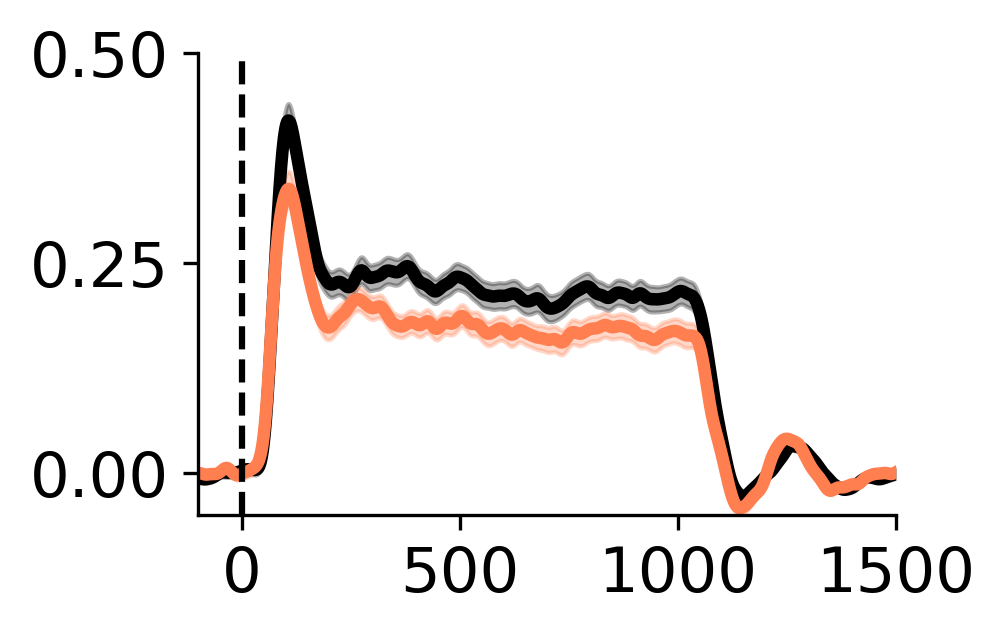

In [6]:
#Mean average grating response before and after DOI
Av_PSTH_PreDOI_Mean = np.nanmean(np.squeeze(Av_PSTH_Norm_PreDOI[:,1400:3000]),axis=0)
Av_PSTH_PostDOI_Mean = np.nanmean(np.squeeze(Av_PSTH_Norm_PostDOI[:,1400:3000]),axis=0)

#STE average Grating Response before and after DOI
Av_PSTH_PreDOI_STE = np.nanstd(np.squeeze(Av_PSTH_Norm_PreDOI[:,1400:3000]),axis=0)/sqrt(len(Av_PSTH_Norm_PreDOI))
Av_PSTH_PostDOI_STE = np.nanstd(np.squeeze(Av_PSTH_Norm_PostDOI[:,1400:3000]),axis=0)/sqrt(len(Av_PSTH_Norm_PostDOI))

# Plotting mean and standard deviation for each group before DOI
fig, axs=plt.subplots(1,1,figsize=(3,2), dpi=300)
for group_mean, group_std, color, label in zip([Av_PSTH_PreDOI_Mean, Av_PSTH_PostDOI_Mean],
                                                [Av_PSTH_PreDOI_STE, Av_PSTH_PostDOI_STE],
                                                ['black','coral'],
                                                ['Pre','Post']):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.xticks(fontsize=15) 
plt.xticks([100, 600, 1100, 1600],labels=[0,500,1000,1500])
plt.yticks([0,.25,.5])
plt.yticks(fontsize=15)  # Adjusting font size for y-axis ticks
plt.ylim(-.05,.5)  # Setting y-axis limit
plt.xlim(0,1600)
plt.axvline(x=100, color='black', linestyle='--')  # Vertical dashed line at x=0

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
#fig.savefig(os.path.join(figpath,'DOI_AverageNormalizedGratingResponse.eps'),dpi=300)

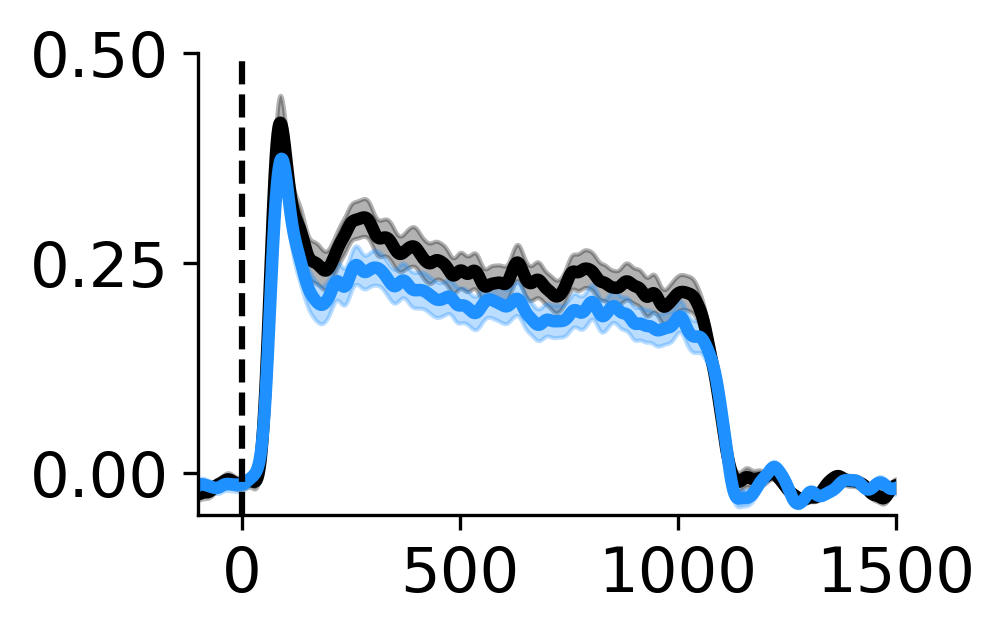

In [7]:
#Mean average grating response before and after DOI
Av_PSTH_Pre_Saline_Mean = np.nanmean(np.squeeze(Av_PSTH_Norm_PreSaline[:,1400:3000]),axis=0)
Av_PSTH_Post_Saline_Mean = np.nanmean(np.squeeze(Av_PSTH_Norm_PostSaline[:,1400:3000]),axis=0)

#STE average Grating Response before and after DOI
Av_PSTH_Pre_Saline_STE = np.nanstd(np.squeeze(Av_PSTH_Norm_PreSaline[:,1400:3000]),axis=0)/sqrt(len(Av_PSTH_Norm_PreSaline))
Av_PSTH_Post_Saline_STE = np.nanstd(np.squeeze(Av_PSTH_Norm_PostSaline[:,1400:3000]),axis=0)/sqrt(len(Av_PSTH_Norm_PostSaline))

# Plotting mean and standard deviation for each group before DOI
fig, axs=plt.subplots(1,1,figsize=(3,2), dpi=300)
for group_mean, group_std, color, label in zip([Av_PSTH_Pre_Saline_Mean, Av_PSTH_Post_Saline_Mean],
                                                [Av_PSTH_Pre_Saline_STE, Av_PSTH_Post_Saline_STE],
                                                ['black','dodgerblue'],
                                                ['Pre','Post']):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.xticks(fontsize=15) 
plt.xticks([100, 600, 1100, 1600],labels=[0,500,1000,1500])
plt.yticks([0,.25,.5])
plt.yticks(fontsize=15)  # Adjusting font size for y-axis ticks
plt.ylim(-.05,.5)  # Setting y-axis limit
plt.xlim(0,1600)
plt.axvline(x=100, color='black', linestyle='--')  # Vertical dashed line at x=0

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
#fig.savefig(os.path.join(figpath,'Saline_AverageNormalizedGratingResponse.eps'),dpi=300)

In [38]:

#Collecting Baseline Subtracted Grating Responses
PSTH_Pre = np.stack(GratingData_DOI['PSTH_Pre'])  #Cluster, TF, SF, Ori, Time  #Baseline Subtracted PSTHs
PSTH_Post = np.stack(GratingData_DOI['PSTH_Post'])  #Cluster, TF, SF, Ori, Time #Baseline Subtracted PSTHs

PSTH_Pre = PSTH_Pre[DOI_Grating_ResponsivetoBoth.astype(bool)]
PSTH_Post = PSTH_Post[DOI_Grating_ResponsivetoBoth.astype(bool)]

PSTH_Pre_OriAv_DOI = np.nanmean(PSTH_Pre,axis=3)
PSTH_Post_OriAv_DOI = np.nanmean(PSTH_Post,axis=3)

PSTH_Pre_OriAv_DOI_Temp = PSTH_Pre_OriAv_DOI.copy()
PSTH_Pre_OriAv_DOI_Temp[PSTH_Pre_OriAv_DOI_Temp<0] = 0
PSTH_Post_OriAv_DOI_Temp = PSTH_Post_OriAv_DOI.copy()
PSTH_Post_OriAv_DOI_Temp[PSTH_Post_OriAv_DOI_Temp<0] = 0

#Generating Time Averaged Responses for Each Grating Response
Pre_MeanResponse_DOI = np.nanmax(PSTH_Pre_OriAv_DOI_Temp[:,:,:,1525:2500],axis= 3)
Post_MeanResponse_DOI = np.nanmax(PSTH_Post_OriAv_DOI_Temp[:,:,:,1525:2500],axis= 3)


PrefTF = np.zeros([int(np.sum(DOI_Grating_ResponsivetoBoth)),2])*np.nan
PrefSF = np.zeros([int(np.sum(DOI_Grating_ResponsivetoBoth)),2])*np.nan
PrefOri = np.zeros([int(np.sum(DOI_Grating_ResponsivetoBoth)),2])*np.nan

WeightedSF_DOI = np.zeros([int(np.sum(DOI_Grating_ResponsivetoBoth)),2])*np.nan
WeightedTF_DOI = np.zeros([int(np.sum(DOI_Grating_ResponsivetoBoth)),2])*np.nan

PreDOI_Pref_Resp = np.zeros([int(np.sum(DOI_Grating_ResponsivetoBoth)),3001])
PostDOI_Pref_Resp = np.zeros([int(np.sum(DOI_Grating_ResponsivetoBoth)),3001])

SF_Tuning_PreDOI = np.zeros([int(np.sum(DOI_Grating_ResponsivetoBoth)),3])
SF_Tuning_PostDOI = np.zeros([int(np.sum(DOI_Grating_ResponsivetoBoth)),3])
TF_Tuning_PreDOI = np.zeros([int(np.sum(DOI_Grating_ResponsivetoBoth)),2])
TF_Tuning_PostDOI = np.zeros([int(np.sum(DOI_Grating_ResponsivetoBoth)),2])


for ii in list(range(0,int(sum(DOI_Grating_ResponsivetoBoth)))):
    Pre_Resp = Pre_MeanResponse_DOI[ii,:,:]
    Pre_Resp[Pre_Resp<0] = 0
    Pref_Resp_Pre_Idx = np.where(Pre_Resp == np.nanmax(Pre_Resp))
    PrefTF[ii,0] = Pref_Resp_Pre_Idx[0]
    PrefSF[ii,0] = Pref_Resp_Pre_Idx[1]
    #PrefOri[ii,0] = Pref_Resp_Pre_Idx[2]
    PreDOI_Pref_Resp[ii,:] = PSTH_Pre_OriAv_DOI[ii,int(PrefTF[ii,0]),int(PrefSF[ii,0]),:]

    Post_Resp = Post_MeanResponse_DOI[ii,:,:]
    Post_Resp[Post_Resp<0] = 0
    Pref_Resp_Post_Idx = np.where(Post_Resp == np.nanmax(Post_Resp))
    PrefTF[ii,1] = Pref_Resp_Post_Idx[0]
    PrefSF[ii,1] = Pref_Resp_Post_Idx[1]
    #PrefOri[ii,1] = Pref_Resp_Post_Idx[2]
    PostDOI_Pref_Resp[ii,:] = PSTH_Post_OriAv_DOI[ii,int(PrefTF[ii,1]),int(PrefSF[ii,1]),:]

    WeightedSF_DOI[ii,0] = ((Pre_Resp[int(PrefTF[ii,0]),0]*0.02) + (Pre_Resp[int(PrefTF[ii,0]),1]*0.08) + (Pre_Resp[int(PrefTF[ii,0]),2]*0.32))/np.sum(Pre_Resp[int(PrefTF[ii,0]),:])
    #WeightedSF_DOI[ii,0] = 0.02*4**(WeightedSF_DOI[ii,0]-1)
    SF_Tuning_PreDOI[ii,:] = [Pre_Resp[int(PrefTF[ii,0]),0],Pre_Resp[int(PrefTF[ii,0]),1],Pre_Resp[int(PrefTF[ii,0]),2]]

    WeightedSF_DOI[ii,1] = ((Post_Resp[int(PrefTF[ii,1]),0]*0.02) + (Post_Resp[int(PrefTF[ii,1]),1]*0.08) + (Post_Resp[int(PrefTF[ii,1]),2]*.32))/np.sum(Post_Resp[int(PrefTF[ii,1]),:])
    #WeightedSF_DOI[ii,1] = 0.02*4**(WeightedSF_DOI[ii,1]-1)
    SF_Tuning_PostDOI[ii,:] = [Post_Resp[int(PrefTF[ii,1]),0],Post_Resp[int(PrefTF[ii,1]),1],Post_Resp[int(PrefTF[ii,1]),2]]

    WeightedTF_DOI[ii,0] = ((Pre_Resp[0,int(PrefSF[ii,0])]*2) + (Pre_Resp[1,int(PrefSF[ii,0])]*8))/ np.sum(Pre_Resp[:,int(PrefSF[ii,0])])
    #WeightedTF_DOI[ii,0] = 2 + (6*(WeightedTF_DOI[ii,0]-1))
    TF_Tuning_PreDOI[ii,:] = [Pre_Resp[0,int(PrefSF[ii,0])],Pre_Resp[1,int(PrefSF[ii,0])]]

    WeightedTF_DOI[ii,1] = ((Post_Resp[0,int(PrefSF[ii,1])]*2) + (Post_Resp[1,int(PrefSF[ii,1])]*8))/ np.sum(Post_Resp[:,int(PrefSF[ii,1])])
    #WeightedTF_DOI[ii,1] = 2 + (6*(WeightedTF_DOI[ii,1]-1))
    TF_Tuning_PostDOI[ii,:] = [Post_Resp[0,int(PrefSF[ii,1])],Post_Resp[1,int(PrefSF[ii,1])]]


In [42]:

#Collecting Baseline Subtracted Grating Responses
PSTH_Pre = np.stack(GratingData_Saline['PSTH_Pre'])  #Cluster, TF, SF, Ori, Time  #Baseline Subtracted PSTHs
PSTH_Post = np.stack(GratingData_Saline['PSTH_Post'])  #Cluster, TF, SF, Ori, Time #Baseline Subtracted PSTHs

PSTH_Pre = PSTH_Pre[Saline_Grating_ResponsivetoBoth.astype(bool)]
PSTH_Post = PSTH_Post[Saline_Grating_ResponsivetoBoth.astype(bool)]

PSTH_Pre_OriAv_Saline = np.nanmean(PSTH_Pre,axis=3)
PSTH_Post_OriAv_Saline = np.nanmean(PSTH_Post,axis=3)

PSTH_Pre_OriAv_Saline_Temp = PSTH_Pre_OriAv_Saline.copy()
PSTH_Pre_OriAv_Saline_Temp[PSTH_Pre_OriAv_Saline_Temp<0] = 0
PSTH_Post_OriAv_Saline_Temp = PSTH_Post_OriAv_Saline.copy()
PSTH_Post_OriAv_Saline_Temp[PSTH_Post_OriAv_Saline_Temp<0] = 0

#Generating Time Averaged Responses for Each Grating Response
Pre_MeanResponse_Saline = np.nanmax(PSTH_Pre_OriAv_Saline_Temp[:,:,:,1525:2500],axis= 3)
Post_MeanResponse_Saline = np.nanmax(PSTH_Post_OriAv_Saline_Temp[:,:,:,1525:2500],axis= 3)


PrefTF = np.zeros([int(np.sum(Saline_Grating_ResponsivetoBoth)),2])*np.nan
PrefSF = np.zeros([int(np.sum(Saline_Grating_ResponsivetoBoth)),2])*np.nan
PrefOri = np.zeros([int(np.sum(Saline_Grating_ResponsivetoBoth)),2])*np.nan

WeightedSF_Saline = np.zeros([int(np.sum(Saline_Grating_ResponsivetoBoth)),2])*np.nan
WeightedTF_Saline = np.zeros([int(np.sum(Saline_Grating_ResponsivetoBoth)),2])*np.nan

PreSaline_Pref_Resp = np.zeros([int(np.sum(Saline_Grating_ResponsivetoBoth)),3001])
PostSaline_Pref_Resp = np.zeros([int(np.sum(Saline_Grating_ResponsivetoBoth)),3001])

SF_Tuning_PreSaline = np.zeros([int(np.sum(Saline_Grating_ResponsivetoBoth)),3])
SF_Tuning_PostSaline = np.zeros([int(np.sum(Saline_Grating_ResponsivetoBoth)),3])
TF_Tuning_PreSaline = np.zeros([int(np.sum(Saline_Grating_ResponsivetoBoth)),2])
TF_Tuning_PostSaline = np.zeros([int(np.sum(Saline_Grating_ResponsivetoBoth)),2])


for ii in list(range(0,int(sum(Saline_Grating_ResponsivetoBoth)))):
    Pre_Resp = Pre_MeanResponse_Saline[ii,:,:]
    Pre_Resp[Pre_Resp<0] = 0
    Pref_Resp_Pre_Idx = np.where(Pre_Resp == np.nanmax(Pre_Resp))
    PrefTF[ii,0] = Pref_Resp_Pre_Idx[0]
    PrefSF[ii,0] = Pref_Resp_Pre_Idx[1]
    #PrefOri[ii,0] = Pref_Resp_Pre_Idx[2]
    PreSaline_Pref_Resp[ii,:] = PSTH_Pre_OriAv_Saline[ii,int(PrefTF[ii,0]),int(PrefSF[ii,0]),:]

    Post_Resp = Post_MeanResponse_Saline[ii,:,:]
    Post_Resp[Post_Resp<0] = 0
    Pref_Resp_Post_Idx = np.where(Post_Resp == np.nanmax(Post_Resp))
    PrefTF[ii,1] = Pref_Resp_Post_Idx[0]
    PrefSF[ii,1] = Pref_Resp_Post_Idx[1]
    #PrefOri[ii,1] = Pref_Resp_Post_Idx[2]
    PostSaline_Pref_Resp[ii,:] = PSTH_Post_OriAv_Saline[ii,int(PrefTF[ii,1]),int(PrefSF[ii,1]),:]

    WeightedSF_Saline[ii,0] = ((Pre_Resp[int(PrefTF[ii,0]),0]*0.02) + (Pre_Resp[int(PrefTF[ii,0]),1]*0.08) + (Pre_Resp[int(PrefTF[ii,0]),2]*.32))/np.sum(Pre_Resp[int(PrefTF[ii,0]),:])
    #WeightedSF_Saline[ii,0] = 0.02*4**(WeightedSF_Saline[ii,0]-1)
    SF_Tuning_PreSaline[ii,:] = [Pre_Resp[int(PrefTF[ii,0]),0],Pre_Resp[int(PrefTF[ii,0]),1],Pre_Resp[int(PrefTF[ii,0]),2]]

    WeightedSF_Saline[ii,1] = ((Post_Resp[int(PrefTF[ii,1]),0]*0.02) + (Post_Resp[int(PrefTF[ii,1]),1]*0.08) + (Post_Resp[int(PrefTF[ii,1]),2]*.32))/np.sum(Post_Resp[int(PrefTF[ii,1]),:])
    #WeightedSF_Saline[ii,1] = 0.02*4**(WeightedSF_Saline[ii,1]-1)
    SF_Tuning_PostSaline[ii,:] = [Post_Resp[int(PrefTF[ii,1]),0],Post_Resp[int(PrefTF[ii,1]),1],Post_Resp[int(PrefTF[ii,1]),2]]

    WeightedTF_Saline[ii,0] = ((Pre_Resp[0,int(PrefSF[ii,0])]*2) + (Pre_Resp[1,int(PrefSF[ii,0])]*8))/ np.sum(Pre_Resp[:,int(PrefSF[ii,0])])
    #WeightedTF_Saline[ii,0] = 2 + (6*(WeightedTF_Saline[ii,0]-1))
    TF_Tuning_PreSaline[ii,:] = [Pre_Resp[0,int(PrefSF[ii,0])],Pre_Resp[1,int(PrefSF[ii,0])]]

    WeightedTF_Saline[ii,1] = ((Post_Resp[0,int(PrefSF[ii,1])]*2) + (Post_Resp[1,int(PrefSF[ii,1])]*8))/ np.sum(Post_Resp[:,int(PrefSF[ii,1])])
    #WeightedTF_Saline[ii,1] = 2 + (6*(WeightedTF_Saline[ii,1]-1))
    TF_Tuning_PostSaline[ii,:] = [Post_Resp[0,int(PrefSF[ii,1])],Post_Resp[1,int(PrefSF[ii,1])]]

<ErrorbarContainer object of 3 artists>

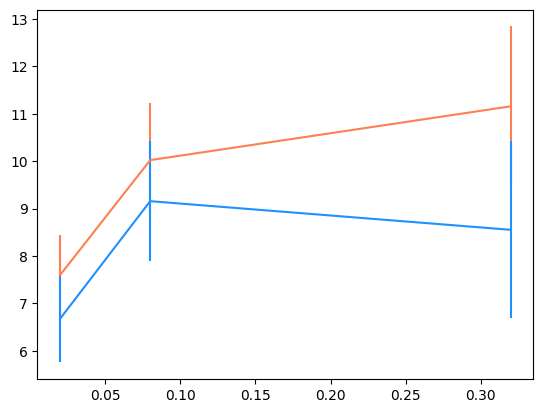

In [65]:
plt.errorbar(x = [.02,.08,.32], y = np.nanmedian(SF_Tuning_PreDOI,axis=0),yerr = np.nanstd(SF_Tuning_PreDOI,axis=0)/np.sqrt(177),color = 'coral')
plt.errorbar(x = [.02,.08,.32], y = np.nanmedian(SF_Tuning_PostDOI,axis=0),yerr = np.nanstd(SF_Tuning_PostDOI,axis=0)/np.sqrt(177),color = 'dodgerblue')

<ErrorbarContainer object of 3 artists>

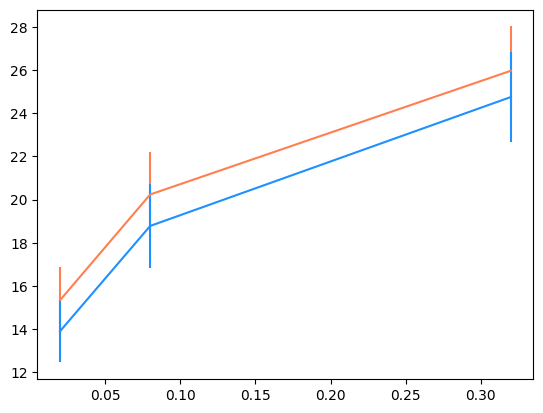

In [67]:
plt.errorbar(x = [.02,.08,.32], y = np.nanmean(SF_Tuning_PreSaline,axis=0),yerr = np.nanstd(SF_Tuning_PreSaline,axis=0)/np.sqrt(177),color = 'coral')
plt.errorbar(x = [.02,.08,.32], y = np.nanmean(SF_Tuning_PostSaline,axis=0),yerr = np.nanstd(SF_Tuning_PostSaline,axis=0)/np.sqrt(177),color = 'dodgerblue')

<ErrorbarContainer object of 3 artists>

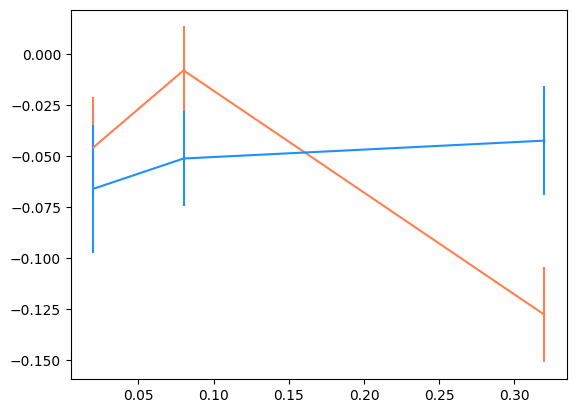

In [66]:
DOI_ModIDX_SF = (SF_Tuning_PostDOI - SF_Tuning_PreDOI) / (SF_Tuning_PostDOI + SF_Tuning_PreDOI)
Saline_ModIDX_SF = (SF_Tuning_PostSaline - SF_Tuning_PreSaline) / (SF_Tuning_PostSaline + SF_Tuning_PreSaline)

plt.errorbar(x = [.02,.08,.32], y = np.nanmean(DOI_ModIDX_SF,axis=0),yerr = np.nanstd(DOI_ModIDX_SF,axis=0)/np.sqrt(177),color = 'coral')
plt.errorbar(x = [.02,.08,.32], y = np.nanmean(Saline_ModIDX_SF,axis=0),yerr = np.nanstd(Saline_ModIDX_SF,axis=0)/np.sqrt(93),color = 'dodgerblue')

<ErrorbarContainer object of 3 artists>

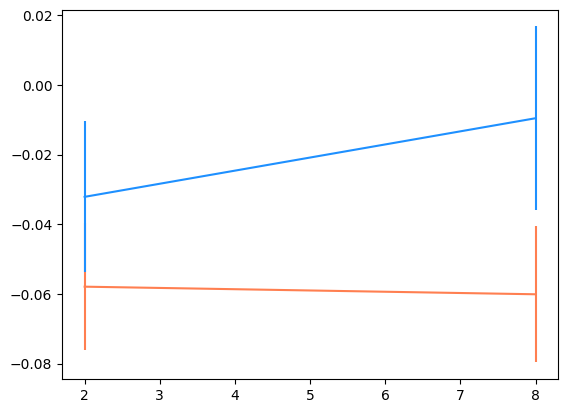

In [68]:
DOI_ModIDX_TF = (TF_Tuning_PostDOI - TF_Tuning_PreDOI) / (TF_Tuning_PostDOI + TF_Tuning_PreDOI)
Saline_ModIDX_TF = (TF_Tuning_PostSaline - TF_Tuning_PreSaline) / (TF_Tuning_PostSaline + TF_Tuning_PreSaline)

plt.errorbar(x = [2,8], y = np.nanmean(DOI_ModIDX_TF,axis=0),yerr = np.nanstd(DOI_ModIDX_TF,axis=0)/np.sqrt(177),color = 'coral')
plt.errorbar(x = [2,8], y = np.nanmean(Saline_ModIDX_TF,axis=0),yerr = np.nanstd(Saline_ModIDX_TF,axis=0)/np.sqrt(93),color = 'dodgerblue')

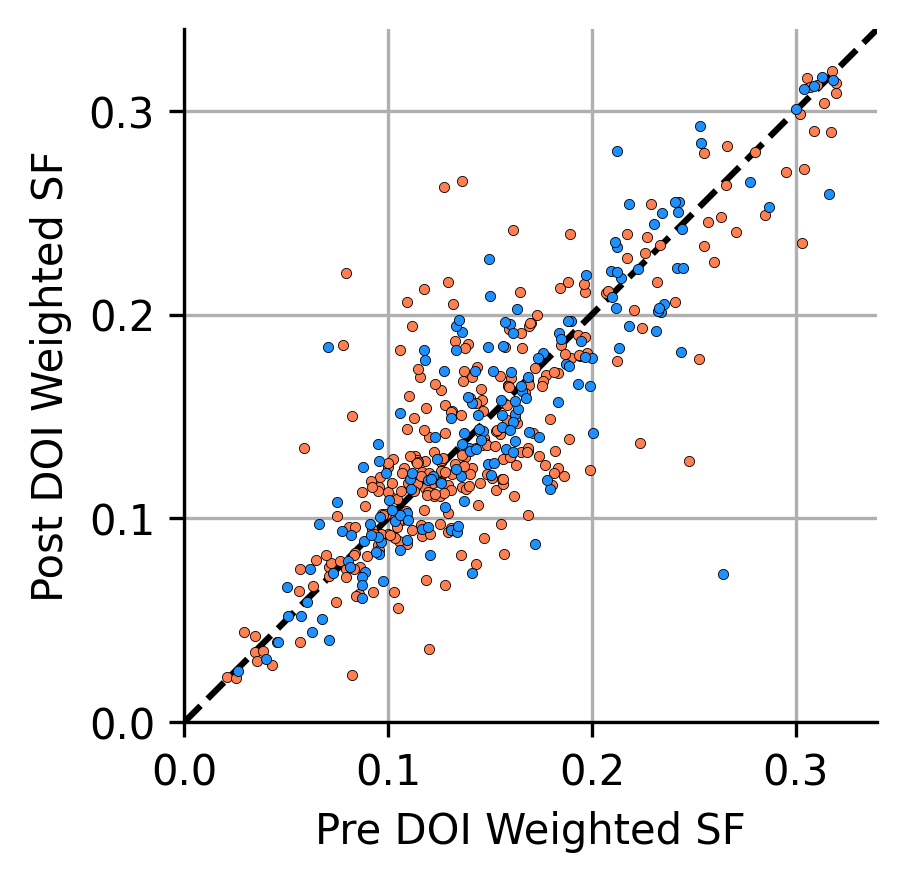

In [12]:
fig, axs=plt.subplots(1,1,figsize=(3,3), dpi=300) 
plt.scatter(WeightedSF_DOI[:,0],WeightedSF_DOI[:,1], color = 'coral', s=6,zorder = 7,edgecolor = 'black',linewidth=.2)  #,color = 'coral',s=10,alpha=.5)
plt.scatter(WeightedSF_Saline[:,0],WeightedSF_Saline[:,1], color = 'dodgerblue', s=6,zorder = 7,edgecolor = 'black',linewidth=.2) #,color='dodgerblue',s=10,alpha=.5)
plt.plot([0,.35],[0,.35],color = 'black',linestyle = '--')
plt.xlabel('Pre DOI Weighted SF')
plt.ylabel('Post DOI Weighted SF')

#plt.xticks(ticks=[.05,.1,.15,.2,.25,.3,.35],labels=[.05,.1,.15,.2,.25,.3,.35])
plt.xticks(ticks=[0,.1,.2,.3])
#plt.xticks(ticks=[0.02,0.08,0.14,0.2,0.26,.32])
plt.xlim([0,.34])
#plt.yticks(ticks=[.05,.1,.15,.2,.25,.3,.35],labels=[.05,.1,.15,.2,.25,.3,.35])
#plt.yticks(ticks=[0.02,0.08,0.14,0.2,0.26,.32])
plt.yticks(ticks=[0,.1,.2,.3])
plt.ylim([0,.34])
plt.grid()
plt.gca().set_rasterized(True)
axs.set_aspect('equal', 'box')
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
fig.savefig(os.path.join(figpath, 'WeightedSF_PrePostInjection.eps'), dpi=300)

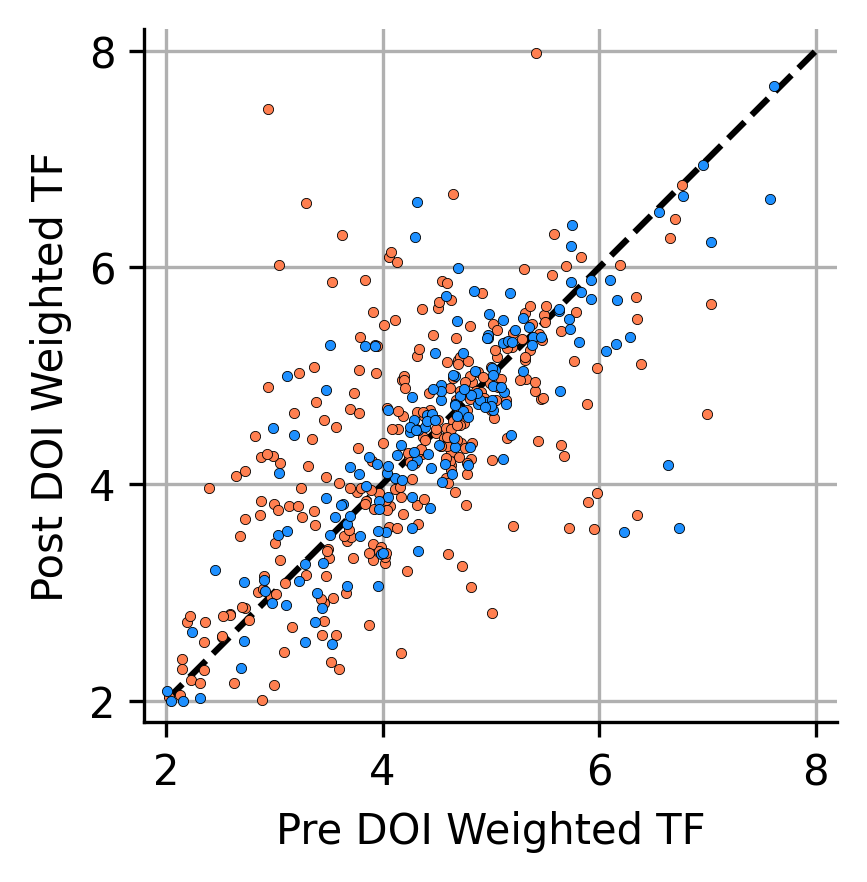

In [13]:
fig, axs=plt.subplots(1,1,figsize=(3,3), dpi=300)


plt.scatter(WeightedTF_DOI[:,0],WeightedTF_DOI[:,1], color = 'coral', s=6,zorder = 7,edgecolor = 'black',linewidth=.2)
plt.scatter(WeightedTF_Saline[:,0],WeightedTF_Saline[:,1], color = 'dodgerblue', s=6,zorder = 7,edgecolor = 'black',linewidth=.2)
plt.plot([2,8],[2,8],color = 'black',linestyle = '--')
plt.xlabel('Pre DOI Weighted TF')
plt.ylabel('Post DOI Weighted TF')
plt.grid()
plt.xticks(ticks=[2,4,6,8],labels=[2,4,6,8])
plt.yticks(ticks=[2,4,6,8],labels=[2,4,6,8])
axs.set_aspect('equal', 'box')
plt.xlim([1.8,8.2])
plt.ylim([1.8,8.2])
#plt.errorbar(np.nanmean(WeightedTF[:,0]),np.nanmean(WeightedTF[:,1]),np.nanstd(WeightedTF[:,0])/sqrt(len(WeightedTF[:,0])),np.nanstd(WeightedTF[:,1])/sqrt(len(WeightedTF[:,1])),zorder=5,color='black')
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
fig.savefig(os.path.join(figpath, 'WeightedTF_PrePostInjection.eps'), dpi=300)

In [47]:
#Finding Gaze Shift Cluster type - DOI

#lightly filtering
kernel_size = 50
kernel = np.ones(kernel_size) / kernel_size

PreDOI_Gaze = np.stack(GazeData_DOI.loc[:,'Pre_Pref_Gaze'])
PreDOI_Gaze_Filt = PreDOI_Gaze.copy()
PostDOI_Gaze = np.stack(GazeData_DOI.loc[:,'Post_Pref_Gaze'])
PostDOI_Gaze_Filt = PreDOI_Gaze.copy()


PreDOI_FR_Threshold = np.zeros(len(PreDOI_Gaze))
PostDOI_FR_Threshold = np.zeros(len(PreDOI_Gaze))
PreDOI_STD_Threshold = np.zeros(len(PreDOI_Gaze))
PostDOI_STD_Threshold = np.zeros(len(PreDOI_Gaze))


for ii in range(0,len(PreDOI_Gaze)):
    PreDOI_Gaze_Filt[ii,:] = np.convolve(PreDOI_Gaze[ii,:], kernel, mode='same')
    PostDOI_Gaze_Filt[ii,:] = np.convolve(PostDOI_Gaze[ii,:], kernel, mode='same')

    PreDOI_FR_Threshold[ii] = calc_fr_modidx(PreDOI_Gaze_Filt[ii,:], 1, trange='fm')
    PreDOI_STD_Threshold[ii] = calc_std_modidx(PreDOI_Gaze_Filt[ii,:], 3.5, trange='fm')

    PostDOI_FR_Threshold[ii] = calc_fr_modidx(PostDOI_Gaze_Filt[ii,:], 1, trange='fm')
    PostDOI_STD_Threshold[ii] = calc_std_modidx(PostDOI_Gaze_Filt[ii,:], 3.5, trange='fm')

PreDOI_Gaze_Responsive = (PreDOI_FR_Threshold + PreDOI_STD_Threshold) - 1
PreDOI_Gaze_Responsive[PreDOI_Gaze_Responsive<1] = 0

PostDOI_Gaze_Responsive = (PostDOI_FR_Threshold + PostDOI_STD_Threshold) - 1
PostDOI_Gaze_Responsive[PostDOI_Gaze_Responsive<1] = 0

DOI_Gaze_ResponsivetoBoth = (PreDOI_Gaze_Responsive + PostDOI_Gaze_Responsive) - 1
DOI_Gaze_ResponsivetoBoth[DOI_Gaze_ResponsivetoBoth<1] = 0 

PreDOI_Based = PreDOI_Gaze_Filt- np.nanmean(PreDOI_Gaze_Filt[:,100:800],axis=1)[:,None]
PostDOI_Based = PostDOI_Gaze_Filt- np.nanmean(PostDOI_Gaze_Filt[:,100:800],axis=1)[:,None]


PreDOI_Gaze_Norm = PreDOI_Based/np.nanmax(PreDOI_Gaze_Filt,axis=1)[:,None]
PostDOI_Gaze_Norm = PostDOI_Based/np.nanmax(PostDOI_Gaze_Filt,axis=1)[:,None]


PreDOI_Gaze_4Clustering = np.nan_to_num(PreDOI_Gaze_Norm.copy(),copy=False)
PreDOI_Gaze_4Clustering[PreDOI_Gaze_Responsive == 0] = np.zeros([2001])

PostDOI_Gaze_4Clustering = np.nan_to_num(PostDOI_Gaze_Norm.copy(),copy=False)
PostDOI_Gaze_4Clustering[PostDOI_Gaze_Responsive == 0] = np.zeros([2001])

# Specify the path to the KMeans model pickle file
km_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/KMeans_PSTH_model_062022.pickle'
pca_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/PCA_PSTH_model_062022.pickle'
with open(km_model_path, 'rb') as f:
    kmeans_model = pickle.load(f)
with open(pca_model_path, 'rb') as f:
    pca = pickle.load(f)

#Transform into PC space.
proj = pca.transform(PreDOI_Gaze_4Clustering[:, 950:1300])
# Only keep required PCs
gproj = proj[:,:4]
# Map onto k-means clusters.
PreDOI_Labels = kmeans_model.predict(gproj)

#Transform into PC space.
proj = pca.transform(PostDOI_Gaze_4Clustering[:, 950:1300])
# Only keep required PCs
gproj = proj[:,:4]
# Map onto k-means clusters.
PostDOI_Labels = kmeans_model.predict(gproj)



DOI_FullyResponsive = (DOI_Gaze_ResponsivetoBoth + DOI_Grating_ResponsivetoBoth) - 1
DOI_FullyResponsive[DOI_FullyResponsive<1] = 0

#############################################################

#Finding Gaze Shift Cluster type - Saline

#lightly filtering
kernel_size = 50
kernel = np.ones(kernel_size) / kernel_size

PreSaline_Gaze = np.stack(GazeData_Saline.loc[:,'Pre_Pref_Gaze'])
PreSaline_Gaze_Filt = PreSaline_Gaze.copy()
PostSaline_Gaze = np.stack(GazeData_Saline.loc[:,'Post_Pref_Gaze'])
PostSaline_Gaze_Filt = PreSaline_Gaze.copy()

PreSaline_FR_Threshold = np.zeros(len(PreSaline_Gaze))
PostSaline_FR_Threshold = np.zeros(len(PreSaline_Gaze))
PreSaline_STD_Threshold = np.zeros(len(PreSaline_Gaze))
PostSaline_STD_Threshold = np.zeros(len(PreSaline_Gaze))

for ii in range(0,len(PreSaline_Gaze)):
    PreSaline_Gaze_Filt[ii,:] = np.convolve(PreSaline_Gaze[ii,:], kernel, mode='same')
    PostSaline_Gaze_Filt[ii,:] = np.convolve(PostSaline_Gaze[ii,:], kernel, mode='same')

    PreSaline_FR_Threshold[ii] = calc_fr_modidx(PreSaline_Gaze_Filt[ii,:], 1, trange='fm')
    PreSaline_STD_Threshold[ii] = calc_std_modidx(PreSaline_Gaze_Filt[ii,:], 3.5, trange='fm')

    PostSaline_FR_Threshold[ii] = calc_fr_modidx(PostSaline_Gaze_Filt[ii,:], 1, trange='fm')
    PostSaline_STD_Threshold[ii] = calc_std_modidx(PostSaline_Gaze_Filt[ii,:], 3.5, trange='fm')

PreSaline_Gaze_Responsive = (PreSaline_FR_Threshold + PreSaline_STD_Threshold) - 1
PreSaline_Gaze_Responsive[PreSaline_Gaze_Responsive<1] = 0

PostSaline_Gaze_Responsive = (PostSaline_FR_Threshold + PostSaline_STD_Threshold) - 1
PostSaline_Gaze_Responsive[PostSaline_Gaze_Responsive<1] = 0

Saline_Gaze_ResponsivetoBoth = (PreSaline_Gaze_Responsive + PostSaline_Gaze_Responsive) - 1
Saline_Gaze_ResponsivetoBoth[Saline_Gaze_ResponsivetoBoth<1] = 0 

PreSaline_Based = PreSaline_Gaze_Filt- np.nanmean(PreSaline_Gaze_Filt[:,100:800],axis=1)[:,None]
PostSaline_Based = PostSaline_Gaze_Filt- np.nanmean(PostSaline_Gaze_Filt[:,100:800],axis=1)[:,None]

PreSaline_Gaze_Norm = PreSaline_Based/np.nanmax(PreSaline_Gaze_Filt,axis=1)[:,None]
PostSaline_Gaze_Norm = PostSaline_Based/np.nanmax(PostSaline_Gaze_Filt,axis=1)[:,None]


PreSaline_Gaze_4Clustering = np.nan_to_num(PreSaline_Gaze_Norm.copy(),copy=False)
PreSaline_Gaze_4Clustering[PreSaline_Gaze_Responsive == 0] = np.zeros([2001])

PostSaline_Gaze_4Clustering = np.nan_to_num(PostSaline_Gaze_Norm.copy(),copy=False)
PostSaline_Gaze_4Clustering[PostSaline_Gaze_Responsive == 0] = np.zeros([2001])

# Specify the path to the KMeans model pickle file
km_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/KMeans_PSTH_model_062022.pickle'
pca_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/PCA_PSTH_model_062022.pickle'
with open(km_model_path, 'rb') as f:
    kmeans_model = pickle.load(f)
with open(pca_model_path, 'rb') as f:
    pca = pickle.load(f)

#Transform into PC space.
proj = pca.transform(PreSaline_Gaze_4Clustering[:, 950:1300])
# Only keep required PCs
gproj = proj[:,:4]
# Map onto k-means clusters.
PreSaline_Labels = kmeans_model.predict(gproj)

#Transform into PC space.
proj = pca.transform(PostSaline_Gaze_4Clustering[:, 950:1300])
# Only keep required PCs
gproj = proj[:,:4]
# Map onto k-means clusters.
PostSaline_Labels = kmeans_model.predict(gproj)



Saline_FullyResponsive = (Saline_Gaze_ResponsivetoBoth + Saline_Grating_ResponsivetoBoth) - 1
Saline_FullyResponsive[Saline_FullyResponsive<1] = 0


###########################################################################################################################

PreDOI_Labels = PreDOI_Labels[DOI_Grating_ResponsivetoBoth.astype(bool)]


PreDOI_Unresp = PreDOI_Labels == 0
PreDOI_Biphasic = PreDOI_Labels == 1
PreDOI_Late = PreDOI_Labels == 2
PreDOI_Early = PreDOI_Labels == 3
PreDOI_Negative = PreDOI_Labels == 4

PostDOI_Unresp = PostDOI_Labels == 0
PostDOI_Biphasic = PostDOI_Labels == 1
PostDOI_Late = PostDOI_Labels == 2
PostDOI_Early = PostDOI_Labels == 3
PostDOI_Negative = PostDOI_Labels == 4

#########################################

PreSaline_Labels = PreSaline_Labels[Saline_Grating_ResponsivetoBoth.astype(bool)]

PreSaline_Unresp = PreSaline_Labels == 0
PreSaline_Biphasic = PreSaline_Labels == 1
PreSaline_Late = PreSaline_Labels == 2
PreSaline_Early = PreSaline_Labels == 3
PreSaline_Negative = PreSaline_Labels == 4

PostSaline_Unresp = PostSaline_Labels == 0
PostSaline_Biphasic = PostSaline_Labels == 1
PostSaline_Late = PostSaline_Labels == 2
PostSaline_Early = PostSaline_Labels == 3
PostSaline_Negative = PostSaline_Labels == 4



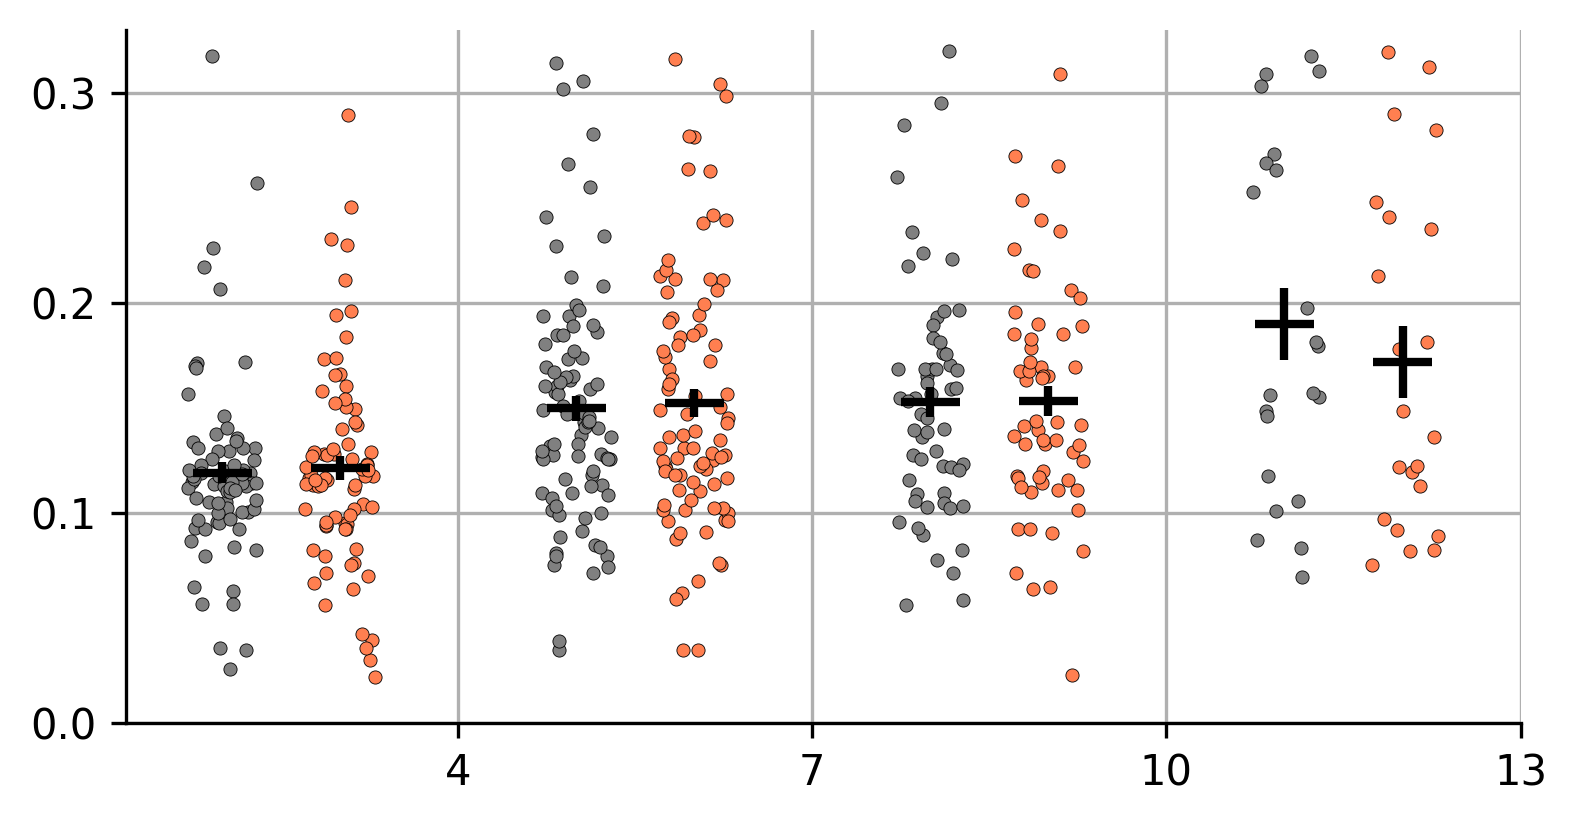

In [19]:
plasma_map = plt.cm.plasma(np.linspace(0,1,15))
clr = [plasma_map[12, :], plasma_map[5,:], plasma_map[8, :], plasma_map[10, :], plasma_map[2, :]]

fig, axs=plt.subplots(1,1,figsize=(6,3), dpi=300)
plt.errorbar(2,np.nanmean(WeightedSF_DOI[PreDOI_Early,0]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Early,0])/sqrt(sum(PreDOI_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(3,np.nanmean(WeightedSF_DOI[PreDOI_Early,1]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Early,1])/sqrt(sum(PreDOI_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(1,sum(PreDOI_Early),.3),WeightedSF_DOI[PreDOI_Early,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(2,sum(PreDOI_Early),.3),WeightedSF_DOI[PreDOI_Early,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(5,np.nanmean(WeightedSF_DOI[PreDOI_Late,0]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Late,0])/sqrt(sum(PreDOI_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(6,np.nanmean(WeightedSF_DOI[PreDOI_Late,1]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Late,1])/sqrt(sum(PreDOI_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(4,sum(PreDOI_Late),.3),WeightedSF_DOI[PreDOI_Late,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(5,sum(PreDOI_Late),.3),WeightedSF_DOI[PreDOI_Late,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(8,np.nanmean(WeightedSF_DOI[PreDOI_Biphasic,0]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Biphasic,0])/sqrt(sum(PreDOI_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(9,np.nanmean(WeightedSF_DOI[PreDOI_Biphasic,1]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Biphasic,1])/sqrt(sum(PreDOI_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(7,sum(PreDOI_Biphasic),.3),WeightedSF_DOI[PreDOI_Biphasic,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(8,sum(PreDOI_Biphasic),.3),WeightedSF_DOI[PreDOI_Biphasic,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(11,np.nanmean(WeightedSF_DOI[PreDOI_Negative,0]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Negative,0])/sqrt(sum(PreDOI_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(12,np.nanmean(WeightedSF_DOI[PreDOI_Negative,1]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Negative,1])/sqrt(sum(PreDOI_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(10,sum(PreDOI_Negative),.3),WeightedSF_DOI[PreDOI_Negative,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(11,sum(PreDOI_Negative),.3),WeightedSF_DOI[PreDOI_Negative,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)

plt.ylim([.01,.33])
#plt.yticks(ticks=[0,.08,.16,.24,.32])
plt.yticks(ticks=[0,.1,.2,.3])
plt.xticks(ticks= [4,7,10,13])
#plt.xlim(1,25)
plt.grid()
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
fig.savefig(os.path.join(figpath,'SF_Pref_by_Cluster_PrePostDOI.eps'),dpi=300)

(-0.25, 0.1)

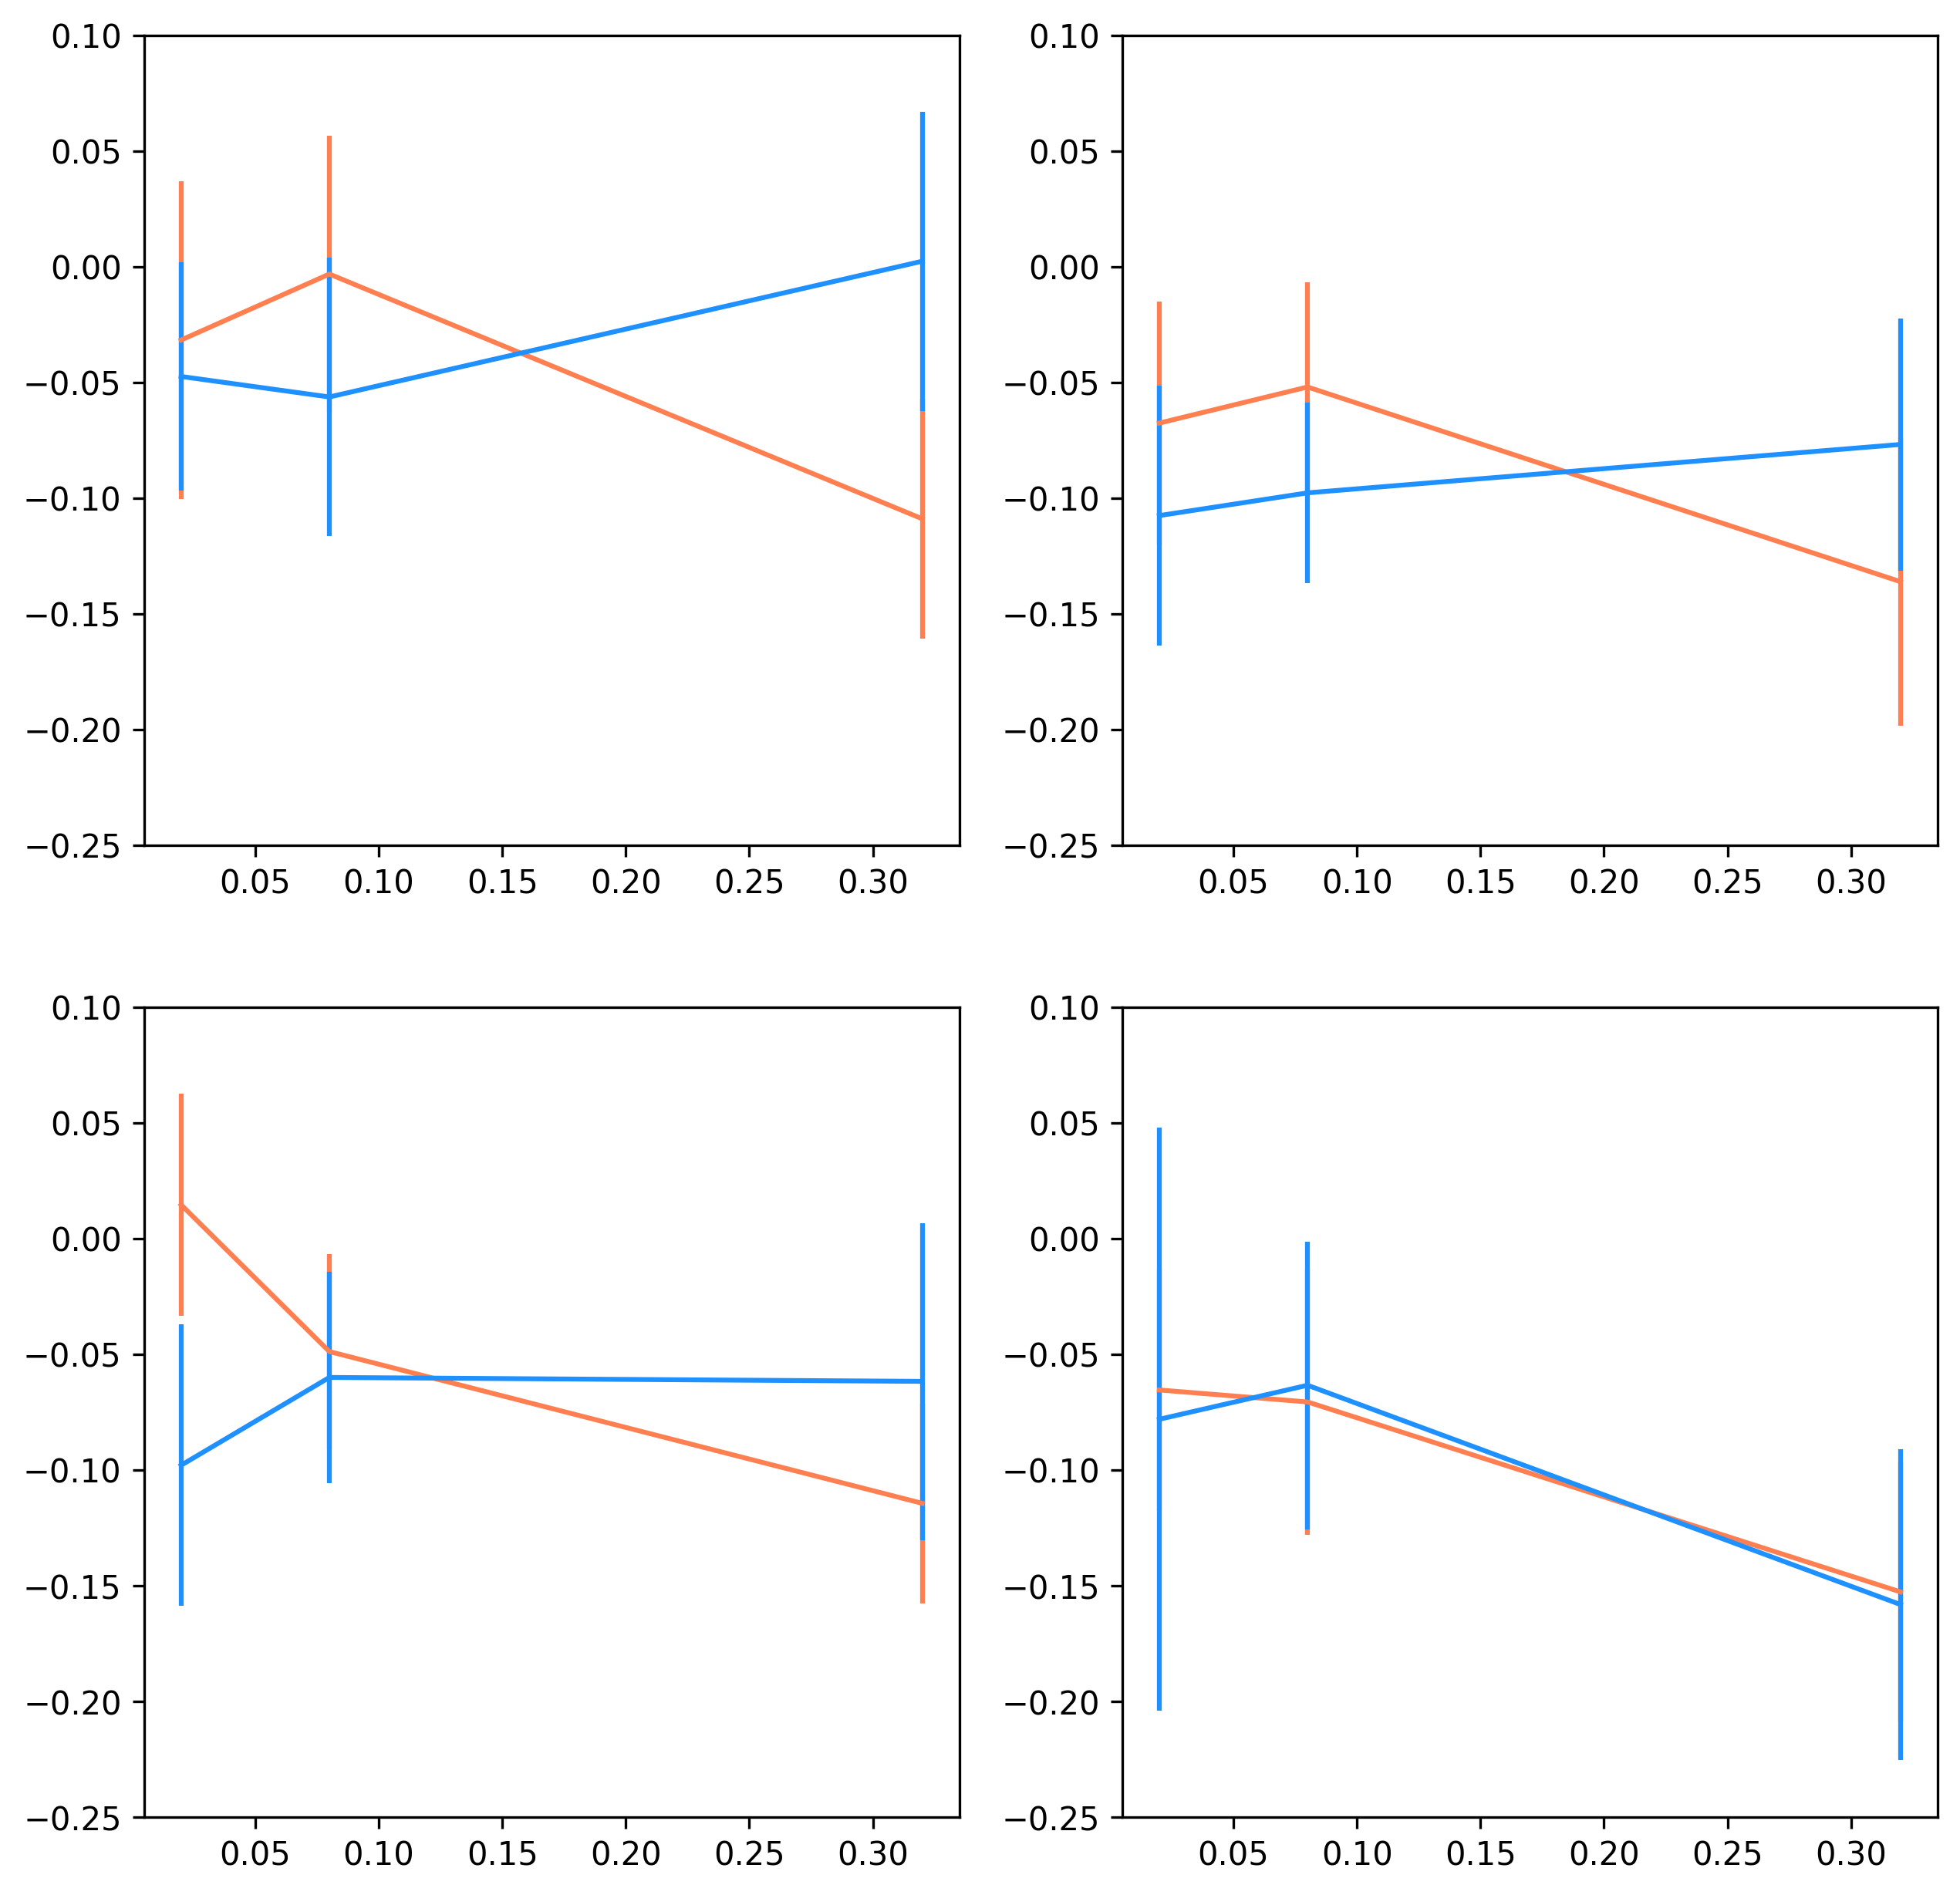

In [56]:

fig, axs=plt.subplots(2,2,figsize=(10,10), dpi=300)
axs = axs.ravel()

axs[0].errorbar(x = [.02,.08,.32], y = np.nanmedian(DOI_ModIDX_SF[PreDOI_Early],axis=0),yerr = np.nanstd(DOI_ModIDX_SF[PreDOI_Early],axis=0)/np.sqrt(np.sum(PreDOI_Early)),color = 'coral')
axs[0].errorbar(x = [.02,.08,.32], y = np.nanmedian(Saline_ModIDX_SF[PreSaline_Early],axis=0),yerr = np.nanstd(Saline_ModIDX_SF[PreSaline_Early],axis=0)/np.sqrt(np.sum(PreSaline_Early)),color = 'dodgerblue')

axs[1].errorbar(x = [.02,.08,.32], y = np.nanmedian(DOI_ModIDX_SF[PreDOI_Late],axis=0),yerr = np.nanstd(DOI_ModIDX_SF[PreDOI_Late],axis=0)/np.sqrt(np.sum(PreDOI_Late)),color = 'coral')
axs[1].errorbar(x = [.02,.08,.32], y = np.nanmedian(Saline_ModIDX_SF[PreSaline_Late],axis=0),yerr = np.nanstd(Saline_ModIDX_SF[PreSaline_Late],axis=0)/np.sqrt(np.sum(PreSaline_Late)),color = 'dodgerblue')

axs[2].errorbar(x = [.02,.08,.32], y = np.nanmedian(DOI_ModIDX_SF[PreDOI_Biphasic],axis=0),yerr = np.nanstd(DOI_ModIDX_SF[PreDOI_Biphasic],axis=0)/np.sqrt(np.sum(PreDOI_Biphasic)),color = 'coral')
axs[2].errorbar(x = [.02,.08,.32], y = np.nanmedian(Saline_ModIDX_SF[PreSaline_Biphasic],axis=0),yerr = np.nanstd(Saline_ModIDX_SF[PreSaline_Biphasic],axis=0)/np.sqrt(np.sum(PreSaline_Biphasic)),color = 'dodgerblue')

axs[3].errorbar(x = [.02,.08,.32], y = np.nanmedian(DOI_ModIDX_SF[PreDOI_Negative],axis=0),yerr = np.nanstd(DOI_ModIDX_SF[PreDOI_Negative],axis=0)/np.sqrt(np.sum(PreDOI_Negative)),color = 'coral')
axs[3].errorbar(x = [.02,.08,.32], y = np.nanmedian(Saline_ModIDX_SF[PreSaline_Negative],axis=0),yerr = np.nanstd(Saline_ModIDX_SF[PreSaline_Negative],axis=0)/np.sqrt(np.sum(PreSaline_Negative)),color = 'dodgerblue')

axs[0].set_ylim(-.25,.1)
axs[1].set_ylim(-.25,.1)
axs[2].set_ylim(-.25,.1)
axs[3].set_ylim(-.25,.1)


(-0.25, 0.1)

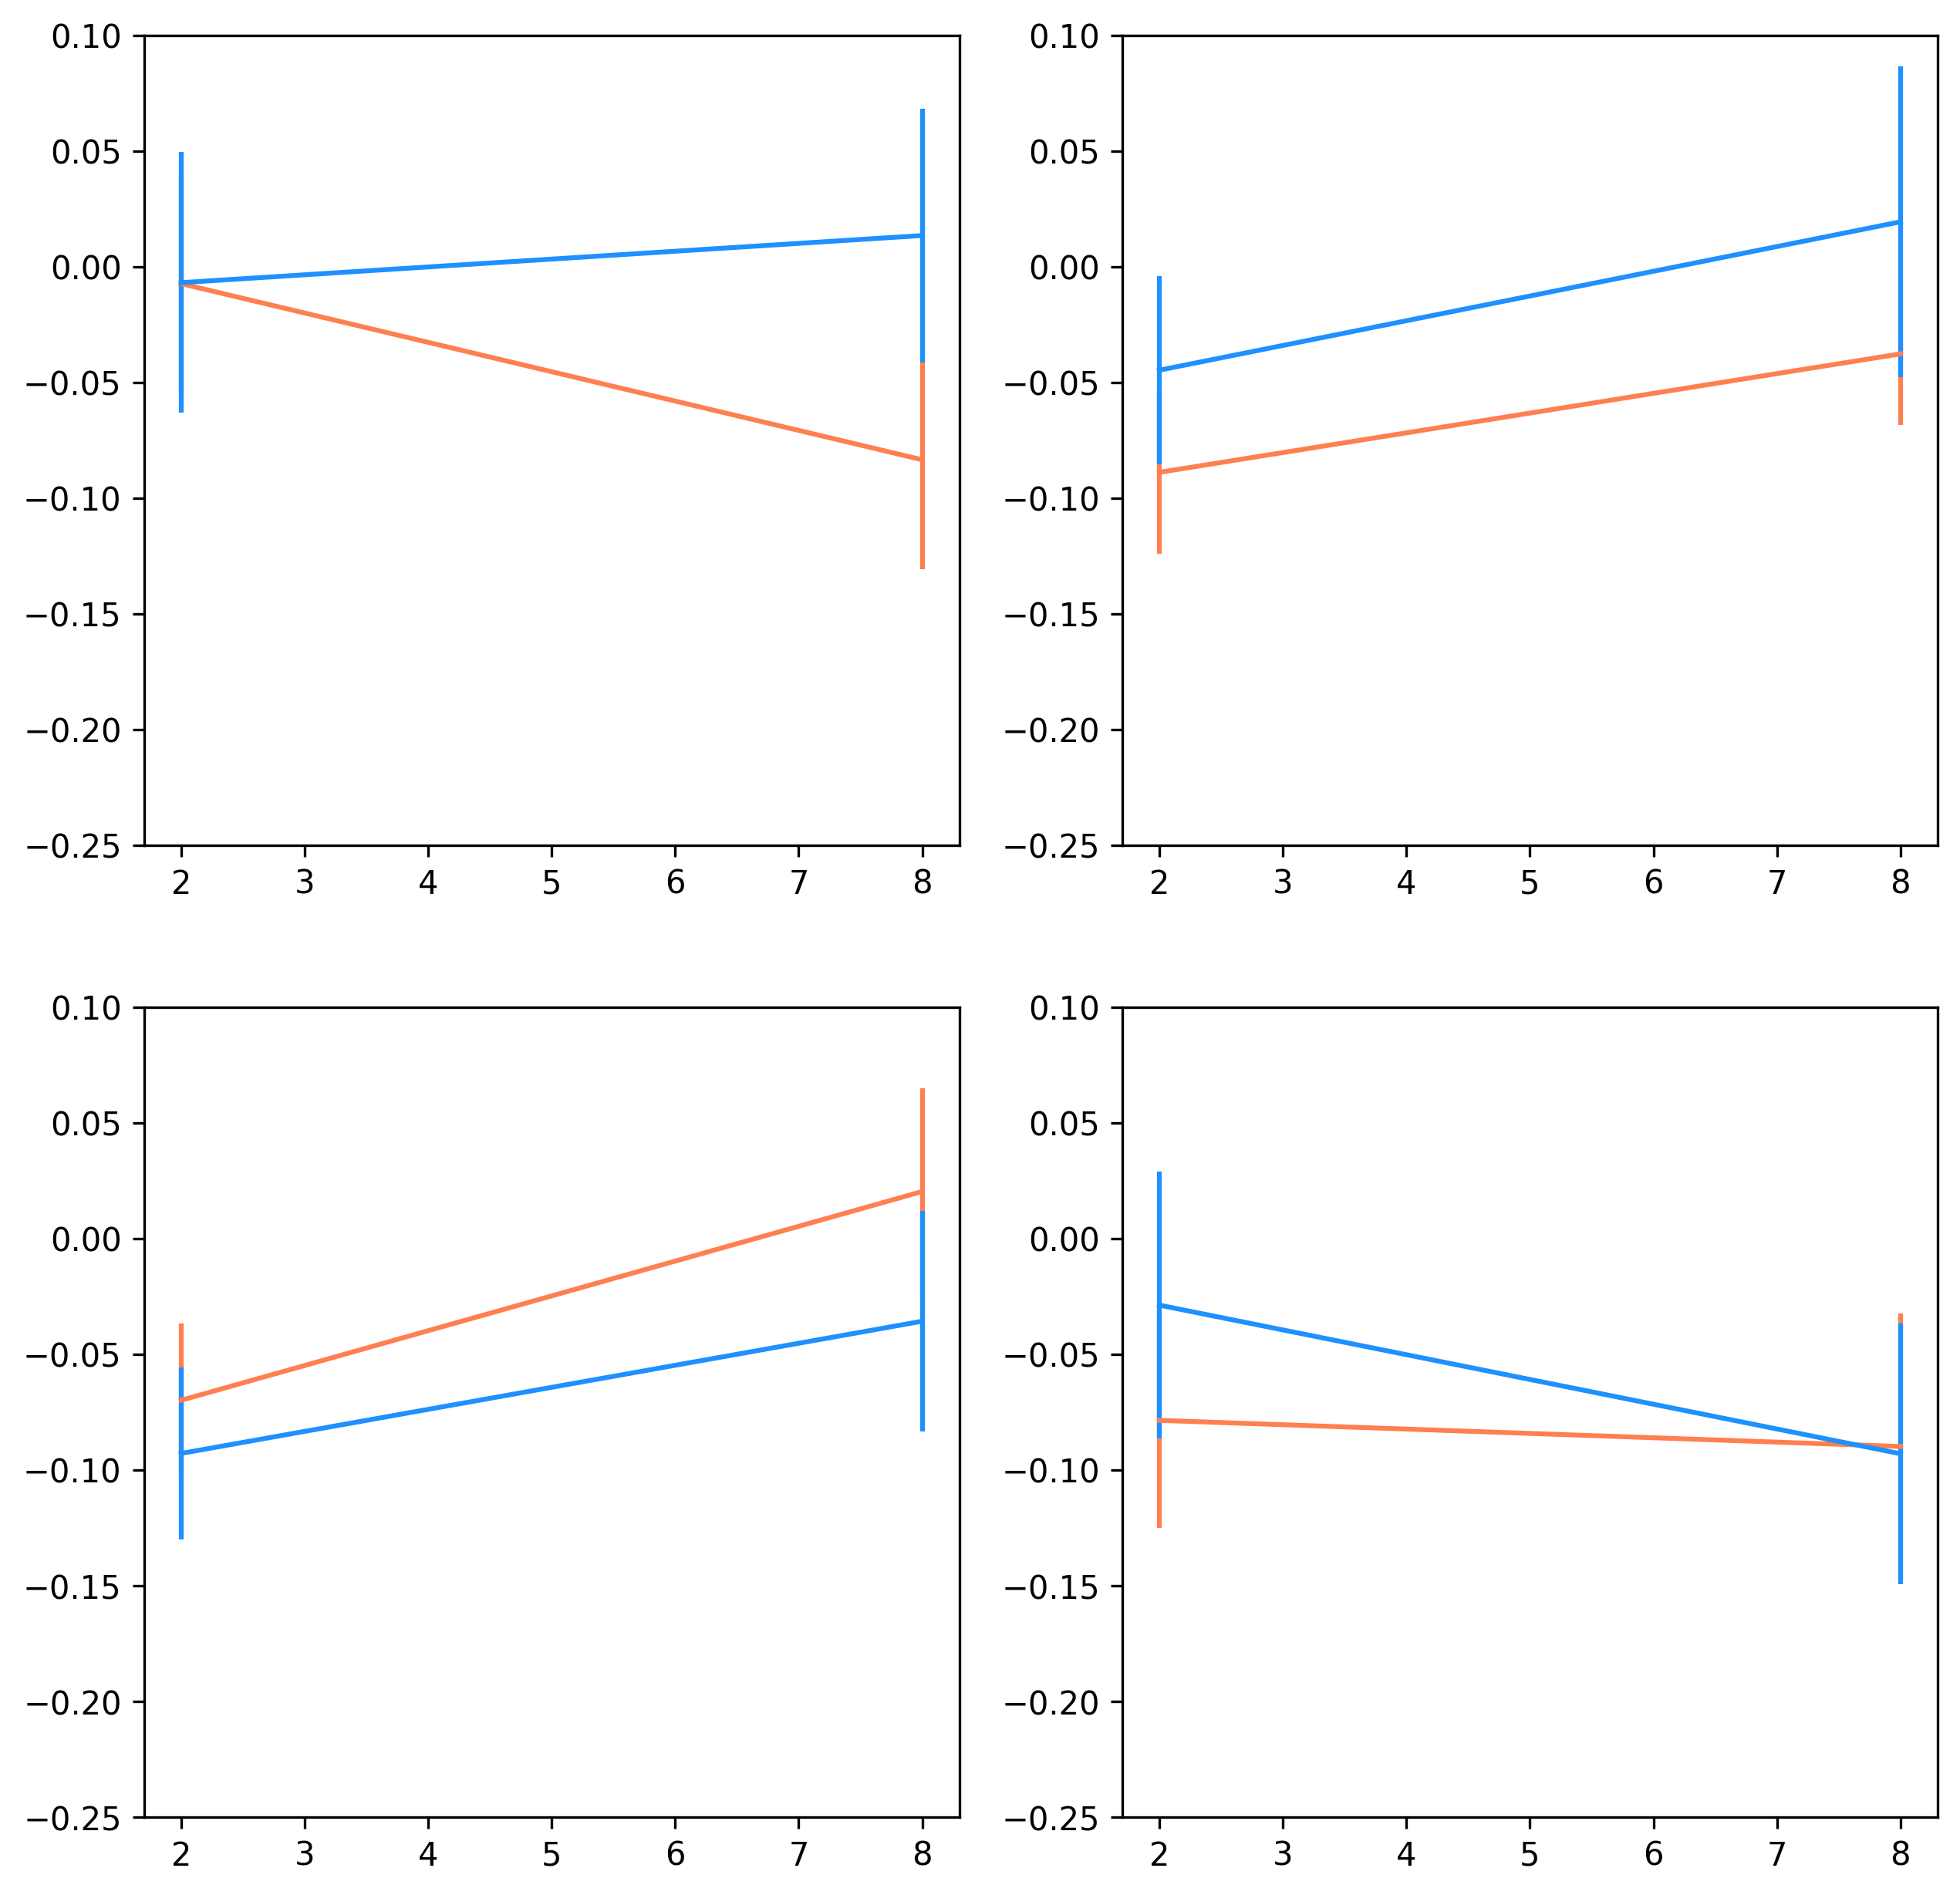

In [61]:

fig, axs=plt.subplots(2,2,figsize=(10,10), dpi=300)
axs = axs.ravel()

axs[0].errorbar(x = [2,8], y = np.nanmedian(DOI_ModIDX_TF[PreDOI_Early],axis=0),yerr = np.nanstd(DOI_ModIDX_TF[PreDOI_Early],axis=0)/np.sqrt(np.sum(PreDOI_Early)),color = 'coral')
axs[0].errorbar(x = [2,8], y = np.nanmedian(Saline_ModIDX_TF[PreSaline_Early],axis=0),yerr = np.nanstd(Saline_ModIDX_TF[PreSaline_Early],axis=0)/np.sqrt(np.sum(PreSaline_Early)),color = 'dodgerblue')

axs[1].errorbar(x = [2,8], y = np.nanmedian(DOI_ModIDX_TF[PreDOI_Late],axis=0),yerr = np.nanstd(DOI_ModIDX_TF[PreDOI_Late],axis=0)/np.sqrt(np.sum(PreDOI_Late)),color = 'coral')
axs[1].errorbar(x = [2,8], y = np.nanmedian(Saline_ModIDX_TF[PreSaline_Late],axis=0),yerr = np.nanstd(Saline_ModIDX_TF[PreSaline_Late],axis=0)/np.sqrt(np.sum(PreSaline_Late)),color = 'dodgerblue')

axs[2].errorbar(x = [2,8], y = np.nanmedian(DOI_ModIDX_TF[PreDOI_Biphasic],axis=0),yerr = np.nanstd(DOI_ModIDX_TF[PreDOI_Biphasic],axis=0)/np.sqrt(np.sum(PreDOI_Biphasic)),color = 'coral')
axs[2].errorbar(x = [2,8], y = np.nanmedian(Saline_ModIDX_TF[PreSaline_Biphasic],axis=0),yerr = np.nanstd(Saline_ModIDX_TF[PreSaline_Biphasic],axis=0)/np.sqrt(np.sum(PreSaline_Biphasic)),color = 'dodgerblue')

axs[3].errorbar(x = [2,8], y = np.nanmedian(DOI_ModIDX_TF[PreDOI_Negative],axis=0),yerr = np.nanstd(DOI_ModIDX_TF[PreDOI_Negative],axis=0)/np.sqrt(np.sum(PreDOI_Negative)),color = 'coral')
axs[3].errorbar(x = [2,8], y = np.nanmedian(Saline_ModIDX_TF[PreSaline_Negative],axis=0),yerr = np.nanstd(Saline_ModIDX_TF[PreSaline_Negative],axis=0)/np.sqrt(np.sum(PreSaline_Negative)),color = 'dodgerblue')

axs[0].set_ylim(-.25,.1)
axs[1].set_ylim(-.25,.1)
axs[2].set_ylim(-.25,.1)
axs[3].set_ylim(-.25,.1)


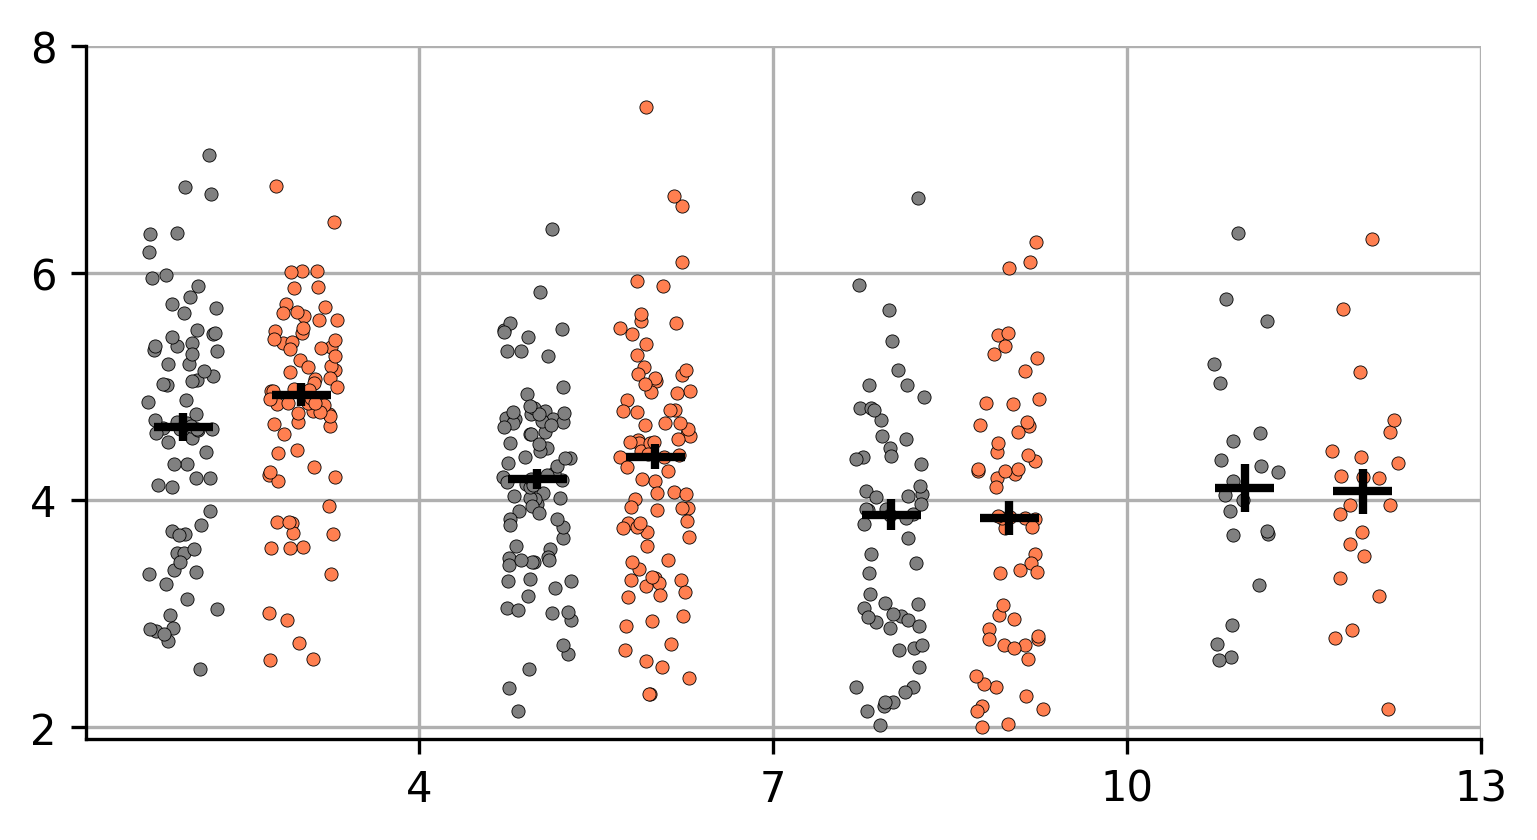

In [20]:
fig, axs=plt.subplots(1,1,figsize=(6,3), dpi=300)
plt.errorbar(2,np.nanmedian(WeightedTF_DOI[PreDOI_Early,0]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Early,0])/sqrt(sum(PreDOI_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(3,np.nanmedian(WeightedTF_DOI[PreDOI_Early,1]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Early,1])/sqrt(sum(PreDOI_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(1,sum(PreDOI_Early),.3),WeightedTF_DOI[PreDOI_Early,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(2,sum(PreDOI_Early),.3),WeightedTF_DOI[PreDOI_Early,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(5,np.nanmedian(WeightedTF_DOI[PreDOI_Late,0]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Late,0])/sqrt(sum(PreDOI_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(6,np.nanmedian(WeightedTF_DOI[PreDOI_Late,1]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Late,1])/sqrt(sum(PreDOI_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(4,sum(PreDOI_Late),.3),WeightedTF_DOI[PreDOI_Late,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(5,sum(PreDOI_Late),.3),WeightedTF_DOI[PreDOI_Late,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(8,np.nanmedian(WeightedTF_DOI[PreDOI_Biphasic,0]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Biphasic,0])/sqrt(sum(PreDOI_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(9,np.nanmedian(WeightedTF_DOI[PreDOI_Biphasic,1]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Biphasic,1])/sqrt(sum(PreDOI_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(7,sum(PreDOI_Biphasic),.3),WeightedTF_DOI[PreDOI_Biphasic,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(8,sum(PreDOI_Biphasic),.3),WeightedTF_DOI[PreDOI_Biphasic,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(11,np.nanmedian(WeightedTF_DOI[PreDOI_Negative,0]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Negative,0])/sqrt(sum(PreDOI_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(12,np.nanmedian(WeightedTF_DOI[PreDOI_Negative,1]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Negative,1])/sqrt(sum(PreDOI_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(10,sum(PreDOI_Negative),.3),WeightedTF_DOI[PreDOI_Negative,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(11,sum(PreDOI_Negative),.3),WeightedTF_DOI[PreDOI_Negative,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)

plt.ylim([1.9,8])
plt.yticks(ticks=[2,4,6,8])
plt.xticks(ticks= [4,7,10,13])
#plt.xlim(1,25)
plt.grid()
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
fig.savefig(os.path.join(figpath,'TF_Pref_by_Cluster_PrePostDOI.eps'),dpi=300)

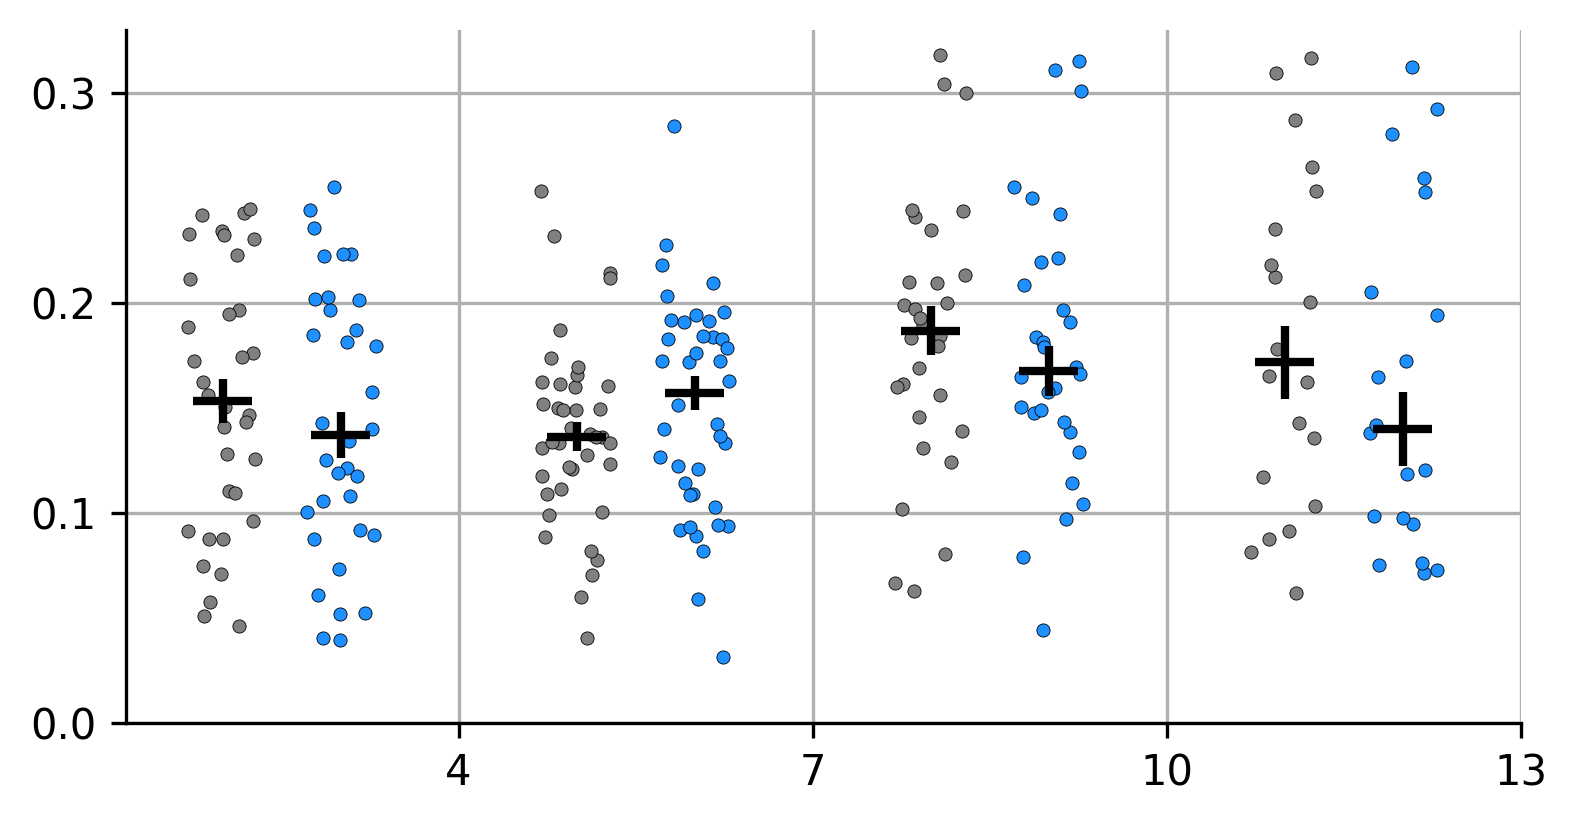

In [21]:

fig, axs=plt.subplots(1,1,figsize=(6,3), dpi=300)
plt.errorbar(2,np.nanmedian(WeightedSF_Saline[PreSaline_Early,0]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Early,0])/sqrt(sum(PreSaline_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(3,np.nanmedian(WeightedSF_Saline[PreSaline_Early,1]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Early,1])/sqrt(sum(PreSaline_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(1,sum(PreSaline_Early),.3),WeightedSF_Saline[PreSaline_Early,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(2,sum(PreSaline_Early),.3),WeightedSF_Saline[PreSaline_Early,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(5,np.nanmedian(WeightedSF_Saline[PreSaline_Late,0]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Late,0])/sqrt(sum(PreSaline_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(6,np.nanmedian(WeightedSF_Saline[PreSaline_Late,1]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Late,1])/sqrt(sum(PreSaline_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(4,sum(PreSaline_Late),.3),WeightedSF_Saline[PreSaline_Late,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(5,sum(PreSaline_Late),.3),WeightedSF_Saline[PreSaline_Late,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(8,np.nanmedian(WeightedSF_Saline[PreSaline_Biphasic,0]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Biphasic,0])/sqrt(sum(PreSaline_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(9,np.nanmedian(WeightedSF_Saline[PreSaline_Biphasic,1]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Biphasic,1])/sqrt(sum(PreSaline_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(7,sum(PreSaline_Biphasic),.3),WeightedSF_Saline[PreSaline_Biphasic,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(8,sum(PreSaline_Biphasic),.3),WeightedSF_Saline[PreSaline_Biphasic,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(11,np.nanmedian(WeightedSF_Saline[PreSaline_Negative,0]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Negative,0])/sqrt(sum(PreSaline_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(12,np.nanmedian(WeightedSF_Saline[PreSaline_Negative,1]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Negative,1])/sqrt(sum(PreSaline_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(10,sum(PreSaline_Negative),.3),WeightedSF_Saline[PreSaline_Negative,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(11,sum(PreSaline_Negative),.3),WeightedSF_Saline[PreSaline_Negative,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)

plt.ylim([.01,.33])
#plt.yticks(ticks=[0,.08,.16,.24,.32])
plt.yticks(ticks=[0,.1,.2,.3])
plt.xticks(ticks= [4,7,10,13])
#plt.xlim(1,25)
plt.grid()
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
fig.savefig(os.path.join(figpath,'SF_Pref_by_Cluster_PrePostSaline.eps'),dpi=300)

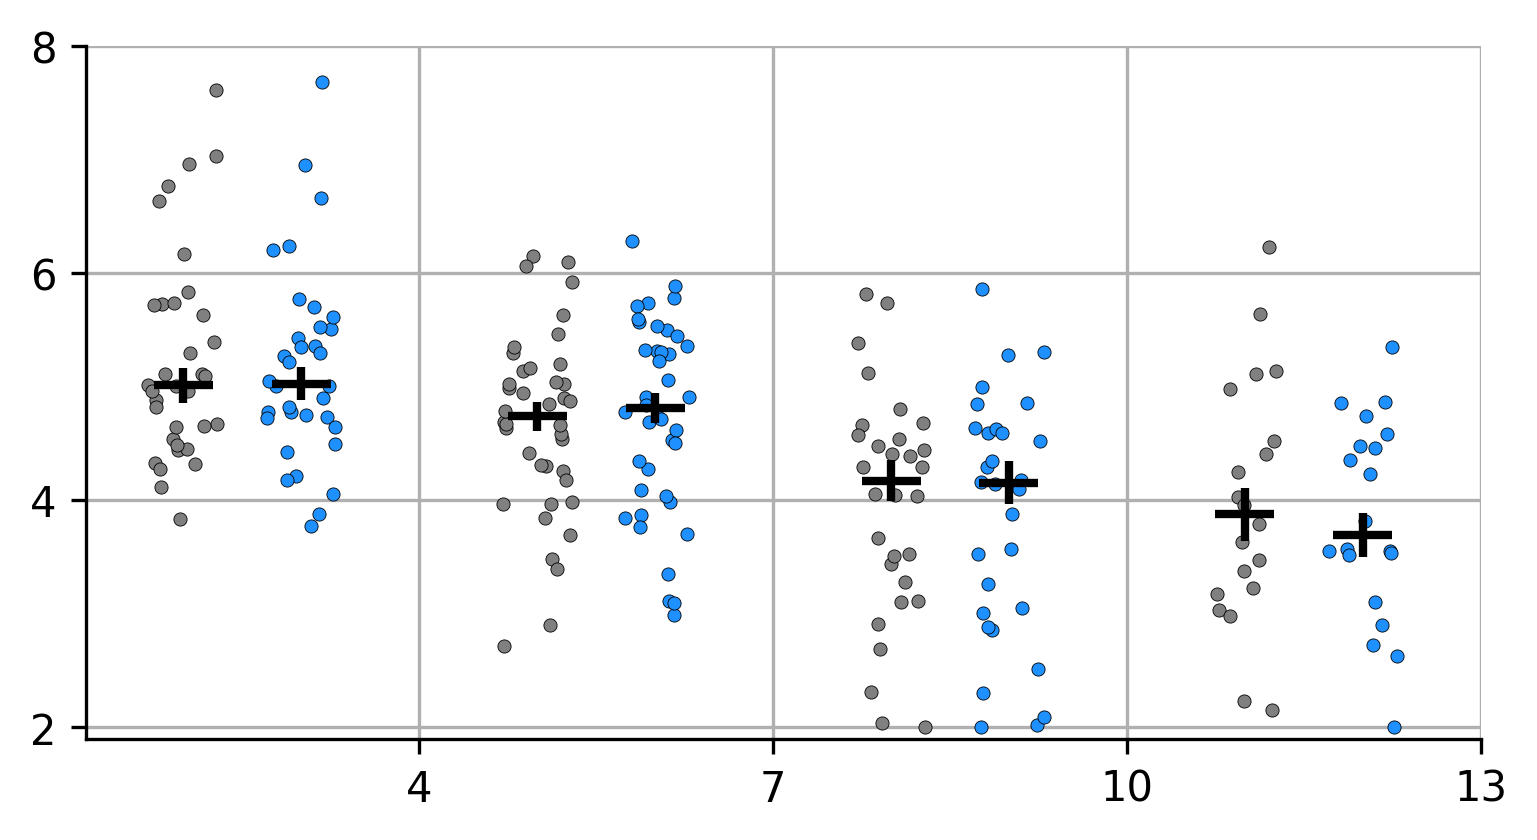

In [22]:

fig, axs=plt.subplots(1,1,figsize=(6,3), dpi=300)
plt.errorbar(2,np.nanmedian(WeightedTF_Saline[PreSaline_Early,0]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Early,0])/sqrt(sum(PreSaline_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(3,np.nanmedian(WeightedTF_Saline[PreSaline_Early,1]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Early,1])/sqrt(sum(PreSaline_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(1,sum(PreSaline_Early),.3),WeightedTF_Saline[PreSaline_Early,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(2,sum(PreSaline_Early),.3),WeightedTF_Saline[PreSaline_Early,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(5,np.nanmedian(WeightedTF_Saline[PreSaline_Late,0]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Late,0])/sqrt(sum(PreSaline_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(6,np.nanmedian(WeightedTF_Saline[PreSaline_Late,1]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Late,1])/sqrt(sum(PreSaline_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(4,sum(PreSaline_Late),.3),WeightedTF_Saline[PreSaline_Late,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(5,sum(PreSaline_Late),.3),WeightedTF_Saline[PreSaline_Late,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(8,np.nanmedian(WeightedTF_Saline[PreSaline_Biphasic,0]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Biphasic,0])/sqrt(sum(PreSaline_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(9,np.nanmedian(WeightedTF_Saline[PreSaline_Biphasic,1]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Biphasic,1])/sqrt(sum(PreSaline_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(7,sum(PreSaline_Biphasic),.3),WeightedTF_Saline[PreSaline_Biphasic,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(8,sum(PreSaline_Biphasic),.3),WeightedTF_Saline[PreSaline_Biphasic,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(11,np.nanmedian(WeightedTF_Saline[PreSaline_Negative,0]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Negative,0])/sqrt(sum(PreSaline_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(12,np.nanmedian(WeightedTF_Saline[PreSaline_Negative,1]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Negative,1])/sqrt(sum(PreSaline_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(10,sum(PreSaline_Negative),.3),WeightedTF_Saline[PreSaline_Negative,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(11,sum(PreSaline_Negative),.3),WeightedTF_Saline[PreSaline_Negative,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)

plt.ylim([1.9,8])
plt.yticks(ticks=[2,4,6,8])
plt.xticks(ticks= [4,7,10,13])
#plt.xlim(1,25)
plt.grid()
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
fig.savefig(os.path.join(figpath,'TF_Pref_by_Cluster_PrePostSaline.eps'),dpi=300)